# Risk diagnosis, prediction, and decision support for fatal traffic accidents in the United States

# Part 1: Data Construction

## 1. Import Raw Files

In [1]:
# import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# read the accident, vehicle and person tables for each year 2015-2024, then stack each into one big table
accident_list = []
vehicle_list = []
person_list = []

for year in range(2015, 2025):
    folder = f"dataset/FARS{year}NationalCSV"
    accident = pd.read_csv(folder + "/accident.csv", encoding="latin1", low_memory=False)
    vehicle = pd.read_csv(folder + "/vehicle.csv", encoding="latin1", low_memory=False)
    person = pd.read_csv(folder + "/person.csv", encoding="latin1", low_memory=False)

    # make column names uppercase, strip spaces and a possible BOM; add the year and a cross-year unique crash id
    for df in [accident, vehicle, person]:
        df.columns = (df.columns.str.replace("ï»¿", "", regex=False)
                                .str.replace("\ufeff", "", regex=False)
                                .str.strip().str.upper())
        df["YEAR_SOURCE"] = year
        df["CASE_KEY"] = df["YEAR_SOURCE"].astype(str) + "_" + df["STATE"].astype(str) + "_" + df["ST_CASE"].astype(str)

    accident_list.append(accident)
    vehicle_list.append(vehicle)
    person_list.append(person)

accident_all = pd.concat(accident_list, ignore_index=True, sort=False)
vehicle_all = pd.concat(vehicle_list, ignore_index=True, sort=False)
person_all = pd.concat(person_list, ignore_index=True, sort=False)

print("accident_all:", accident_all.shape)
print("vehicle_all:", vehicle_all.shape)
print("person_all:", person_all.shape)

accident_all: (358460, 93)
vehicle_all: (550867, 223)
person_all: (882308, 152)


## 2. Construct Accident-Level Data

In [3]:
# keep only the columns we need from the accident table, and rebuild a unique crash id
accident_keep_cols = ["STATE", "STATENAME", "ST_CASE", "YEAR", "MONTH", "DAY_WEEK", "HOUR",
                      "FATALS", "PEDS", "PERSONS", "VE_TOTAL", "RUR_URB", "LGT_COND",
                      "WEATHER", "LATITUDE", "LONGITUD"]
accident_selected = accident_all[accident_keep_cols].copy()

accident_selected["CASE_KEY"] = (accident_selected["YEAR"].astype(str) + "_"
                                 + accident_selected["STATE"].astype(str) + "_"
                                 + accident_selected["ST_CASE"].astype(str))

accident_selected.head()

,STATE,STATENAME,ST_CASE,YEAR,MONTH,DAY_WEEK,HOUR,FATALS,PEDS,PERSONS,VE_TOTAL,RUR_URB,LGT_COND,WEATHER,LATITUDE,LONGITUD,CASE_KEY
0,1,Alabama,10001,2015,1,5,2,1,0,1,1,1,2,1,33.878653,-87.325328,2015_1_10001
1,1,Alabama,10002,2015,1,5,22,1,0,1,1,1,2,10,34.910442,-86.908708,2015_1_10002
2,1,Alabama,10003,2015,1,5,1,1,0,2,1,1,2,1,32.142006,-85.758456,2015_1_10003
3,1,Alabama,10004,2015,1,1,0,1,0,1,1,1,2,10,31.439814,-85.510300,2015_1_10004
4,1,Alabama,10005,2015,1,4,7,1,0,2,2,2,1,1,31.319331,-85.515100,2015_1_10005


In [4]:
# build 0/1 risk flags at the crash level (multi-fatal, pedestrian, rural, dark, bad weather, weekend, night)
accident_features = accident_selected.copy()

for col in ["FATALS", "PEDS", "RUR_URB", "LGT_COND", "WEATHER", "DAY_WEEK", "HOUR"]:
    accident_features[col] = pd.to_numeric(accident_features[col], errors="coerce")

accident_features["multi_fatal_crash"] = (accident_features["FATALS"] >= 2).astype(int)          # 2 or more deaths
accident_features["pedestrian_involved"] = (accident_features["PEDS"] > 0).astype(int)           # pedestrian involved
accident_features["rural"] = (accident_features["RUR_URB"] == 1).astype(int)                     # rural road
accident_features["dark_condition"] = accident_features["LGT_COND"].isin([2, 3, 6]).astype(int)  # dark lighting
accident_features["adverse_weather"] = accident_features["WEATHER"].isin([2, 3, 4, 5, 6, 7, 8, 11, 12]).astype(int)  # adverse weather
accident_features["weekend"] = accident_features["DAY_WEEK"].isin([1, 7]).astype(int)            # weekend
accident_features["night_time"] = ((accident_features["HOUR"] >= 20) | (accident_features["HOUR"] <= 5)).astype(int)  # night

accident_features.head()

,STATE,STATENAME,ST_CASE,YEAR,MONTH,DAY_WEEK,HOUR,FATALS,PEDS,PERSONS,...,LATITUDE,LONGITUD,CASE_KEY,multi_fatal_crash,pedestrian_involved,rural,dark_condition,adverse_weather,weekend,night_time
0,1,Alabama,10001,2015,1,5,2,1,0,1,...,33.878653,-87.325328,2015_1_10001,0,0,1,1,0,0,1
1,1,Alabama,10002,2015,1,5,22,1,0,1,...,34.910442,-86.908708,2015_1_10002,0,0,1,1,0,0,1
2,1,Alabama,10003,2015,1,5,1,1,0,2,...,32.142006,-85.758456,2015_1_10003,0,0,1,1,0,0,1
3,1,Alabama,10004,2015,1,1,0,1,0,1,...,31.439814,-85.510300,2015_1_10004,0,0,1,1,0,1,1
4,1,Alabama,10005,2015,1,4,7,1,0,2,...,31.319331,-85.515100,2015_1_10005,0,0,0,0,0,0,0


In [5]:
# check the distribution of each flag we just made
new_accident_vars = ["multi_fatal_crash", "pedestrian_involved", "rural", "dark_condition",
                     "adverse_weather", "weekend", "night_time"]
for col in new_accident_vars:
    print(col)
    print(accident_features[col].value_counts(dropna=False))
    print(accident_features[col].value_counts(normalize=True, dropna=False).round(4))
    print()

multi_fatal_crash
multi_fatal_crash
0    333455
1     25005
Name: count, dtype: int64
multi_fatal_crash
0    0.9302
1    0.0698
Name: proportion, dtype: float64

pedestrian_involved
pedestrian_involved
0    280586
1     77874
Name: count, dtype: int64
pedestrian_involved
0    0.7828
1    0.2172
Name: proportion, dtype: float64

rural
rural
0    205913
1    152547
Name: count, dtype: int64
rural
0    0.5744
1    0.4256
Name: proportion, dtype: float64

dark_condition
dark_condition
0    183119
1    175341
Name: count, dtype: int64
dark_condition
0    0.5108
1    0.4892
Name: proportion, dtype: float64

adverse_weather
adverse_weather
0    323991
1     34469
Name: count, dtype: int64
adverse_weather
0    0.9038
1    0.0962
Name: proportion, dtype: float64

weekend
weekend
0    240465
1    117995
Name: count, dtype: int64
weekend
0    0.6708
1    0.3292
Name: proportion, dtype: float64

night_time
night_time
0    208558
1    149902
Name: count, dtype: int64
night_time
0    0.5818
1    0.4

## 3. Construct Vehicle-Level Variables

In [6]:
# keep the columns we need from the vehicle table and add the crash id
vehicle_keep_cols = ["STATE", "ST_CASE", "VEH_NO", "DR_DRINK", "SPEEDREL", "BODY_TYP",
                     "MOD_YEAR", "DEATHS", "PREV_ACC", "PREV_DWI", "PREV_SPD"]
vehicle_selected = vehicle_all[vehicle_keep_cols].copy()
vehicle_selected["YEAR_SOURCE"] = vehicle_all["YEAR_SOURCE"].values

vehicle_selected["CASE_KEY"] = (vehicle_selected["YEAR_SOURCE"].astype(str) + "_"
                                + vehicle_selected["STATE"].astype(str) + "_"
                                + vehicle_selected["ST_CASE"].astype(str))

vehicle_selected.head()

,STATE,ST_CASE,VEH_NO,DR_DRINK,SPEEDREL,BODY_TYP,MOD_YEAR,DEATHS,PREV_ACC,PREV_DWI,PREV_SPD,YEAR_SOURCE,CASE_KEY
0,1,10001,1,1,0,31,2003,1,1,0,1,2015,2015_1_10001
1,1,10002,1,0,4,4,2006,1,2,0,0,2015,2015_1_10002
2,1,10003,1,1,0,4,2008,1,2,0,1,2015,2015_1_10003
3,1,10004,1,1,0,31,2005,1,0,0,0,2015,2015_1_10004
4,1,10005,1,0,0,3,2006,1,0,0,0,2015,2015_1_10005


In [7]:
# convert vehicle fields to numbers and build a few vehicle-level 0/1 flags (drunk, speeding, prior DWI, prior speeding)
vehicle_features = vehicle_selected.copy()
for col in ["DR_DRINK", "SPEEDREL", "VEH_NO", "PREV_DWI", "PREV_SPD"]:
    vehicle_features[col] = pd.to_numeric(vehicle_features[col], errors="coerce")

vehicle_features["vehicle_alcohol_related"] = (vehicle_features["DR_DRINK"] == 1).astype(int)
vehicle_features["vehicle_speed_related"] = vehicle_features["SPEEDREL"].isin([2, 3, 4, 5]).astype(int)
vehicle_features["vehicle_any_prior_dwi"] = (vehicle_features["PREV_DWI"] > 0).astype(int)
vehicle_features["vehicle_any_prior_speed"] = (vehicle_features["PREV_SPD"] > 0).astype(int)

vehicle_features.head()

,STATE,ST_CASE,VEH_NO,DR_DRINK,SPEEDREL,BODY_TYP,MOD_YEAR,DEATHS,PREV_ACC,PREV_DWI,PREV_SPD,YEAR_SOURCE,CASE_KEY,vehicle_alcohol_related,vehicle_speed_related,vehicle_any_prior_dwi,vehicle_any_prior_speed
0,1,10001,1,1,0,31,2003,1,1,0,1,2015,2015_1_10001,1,0,0,1
1,1,10002,1,0,4,4,2006,1,2,0,0,2015,2015_1_10002,0,1,0,0
2,1,10003,1,1,0,4,2008,1,2,0,1,2015,2015_1_10003,1,0,0,1
3,1,10004,1,1,0,31,2005,1,0,0,0,2015,2015_1_10004,1,0,0,0
4,1,10005,1,0,0,3,2006,1,0,0,0,2015,2015_1_10005,0,0,0,0


In [8]:
# check the distribution of the vehicle-level flags
new_vehicle_vars = ["vehicle_alcohol_related", "vehicle_speed_related",
                    "vehicle_any_prior_dwi", "vehicle_any_prior_speed"]
for col in new_vehicle_vars:
    print(col)
    print(vehicle_features[col].value_counts(dropna=False))
    print(vehicle_features[col].value_counts(normalize=True, dropna=False).round(4))
    print()

vehicle_alcohol_related
vehicle_alcohol_related
0    453782
1     97085
Name: count, dtype: int64
vehicle_alcohol_related
0    0.8238
1    0.1762
Name: proportion, dtype: float64

vehicle_speed_related
vehicle_speed_related
0    451447
1     99420
Name: count, dtype: int64
vehicle_speed_related
0    0.8195
1    0.1805
Name: proportion, dtype: float64

vehicle_any_prior_dwi
vehicle_any_prior_dwi
0    508294
1     42573
Name: count, dtype: int64
vehicle_any_prior_dwi
0    0.9227
1    0.0773
Name: proportion, dtype: float64

vehicle_any_prior_speed
vehicle_any_prior_speed
0    427263
1    123604
Name: count, dtype: int64
vehicle_any_prior_speed
0    0.7756
1    0.2244
Name: proportion, dtype: float64



In [9]:
# vehicle data is one row per vehicle, aggregate it to one row per crash
vehicle_agg = (vehicle_features
               .groupby("CASE_KEY", as_index=False)
               .agg(alcohol_related=("vehicle_alcohol_related", "max"),
                    speed_related=("vehicle_speed_related", "max"),
                    num_vehicles=("VEH_NO", "nunique"),
                    any_prior_dwi=("vehicle_any_prior_dwi", "max"),
                    any_prior_speed=("vehicle_any_prior_speed", "max")))

vehicle_agg.head()

,CASE_KEY,alcohol_related,speed_related,num_vehicles,any_prior_dwi,any_prior_speed
0,2015_10_100001,1,1,1,1,0
1,2015_10_100002,1,1,1,0,0
2,2015_10_100003,1,1,1,0,1
3,2015_10_100004,0,0,2,1,1
4,2015_10_100005,0,0,2,1,1


In [10]:
# merge the vehicle aggregates back to the accident table; unmatched crashes get NaN, fill with 0 and make int
crash_vehicle_features = accident_features.merge(vehicle_agg, on="CASE_KEY", how="left")

for col in ["alcohol_related", "speed_related", "num_vehicles", "any_prior_dwi", "any_prior_speed"]:
    crash_vehicle_features[col] = crash_vehicle_features[col].fillna(0).astype(int)

crash_vehicle_features.head()

,STATE,STATENAME,ST_CASE,YEAR,MONTH,DAY_WEEK,HOUR,FATALS,PEDS,PERSONS,...,rural,dark_condition,adverse_weather,weekend,night_time,alcohol_related,speed_related,num_vehicles,any_prior_dwi,any_prior_speed
0,1,Alabama,10001,2015,1,5,2,1,0,1,...,1,1,0,0,1,1,0,1,0,1
1,1,Alabama,10002,2015,1,5,22,1,0,1,...,1,1,0,0,1,0,1,1,0,0
2,1,Alabama,10003,2015,1,5,1,1,0,2,...,1,1,0,0,1,1,0,1,0,1
3,1,Alabama,10004,2015,1,1,0,1,0,1,...,1,1,0,1,1,1,0,1,0,0
4,1,Alabama,10005,2015,1,4,7,1,0,2,...,0,0,0,0,0,0,0,2,0,0


## 4. Construct Person-Level Variables

In [11]:
# keep the columns we need from the person table and add the crash id
person_keep_cols = ["STATE", "ST_CASE", "PER_TYP", "INJ_SEV", "AGE", "SEX",
                    "REST_USE", "HELM_USE", "DRINKING"]
person_selected = person_all[person_keep_cols].copy()
person_selected["YEAR_SOURCE"] = person_all["YEAR_SOURCE"].values

person_selected["CASE_KEY"] = (person_selected["YEAR_SOURCE"].astype(str) + "_"
                               + person_selected["STATE"].astype(str) + "_"
                               + person_selected["ST_CASE"].astype(str))

person_selected.head()

,STATE,ST_CASE,PER_TYP,INJ_SEV,AGE,SEX,REST_USE,HELM_USE,DRINKING,YEAR_SOURCE,CASE_KEY
0,1,10001,1,4,68,1,7,NaN,9,2015,2015_1_10001
1,1,10002,1,4,49,1,7,NaN,0,2015,2015_1_10002
2,1,10003,1,4,31,1,7,NaN,1,2015,2015_1_10003
3,1,10003,2,2,20,2,7,NaN,8,2015,2015_1_10003
4,1,10004,1,4,40,1,7,NaN,1,2015,2015_1_10004


In [12]:
# convert person fields to numbers and build person-level 0/1 flags (fatal, young driver, elderly, unrestrained occupant)
person_features = person_selected.copy()
for col in ["PER_TYP", "INJ_SEV", "AGE", "SEX", "REST_USE", "HELM_USE", "DRINKING"]:
    person_features[col] = pd.to_numeric(person_features[col], errors="coerce")

person_features["person_fatal"] = (person_features["INJ_SEV"] == 4).astype(int)
person_features["person_young_driver"] = ((person_features["PER_TYP"] == 1)
                                          & (person_features["AGE"] >= 16)
                                          & (person_features["AGE"] <= 24)).astype(int)
person_features["person_elderly"] = ((person_features["AGE"] >= 65)
                                     & (person_features["AGE"] < 998)).astype(int)
person_features["person_unrestrained_occupant"] = (person_features["PER_TYP"].isin([1, 2, 3, 9])
                                                   & (person_features["REST_USE"] == 20)).astype(int)

person_features.head()

,STATE,ST_CASE,PER_TYP,INJ_SEV,AGE,SEX,REST_USE,HELM_USE,DRINKING,YEAR_SOURCE,CASE_KEY,person_fatal,person_young_driver,person_elderly,person_unrestrained_occupant
0,1,10001,1,4,68,1,7,NaN,9,2015,2015_1_10001,1,0,1,0
1,1,10002,1,4,49,1,7,NaN,0,2015,2015_1_10002,1,0,0,0
2,1,10003,1,4,31,1,7,NaN,1,2015,2015_1_10003,1,0,0,0
3,1,10003,2,2,20,2,7,NaN,8,2015,2015_1_10003,0,0,0,0
4,1,10004,1,4,40,1,7,NaN,1,2015,2015_1_10004,1,0,0,0


In [13]:
# check the distribution of the person-level flags
new_person_vars = ["person_fatal", "person_young_driver", "person_elderly", "person_unrestrained_occupant"]
for col in new_person_vars:
    print(col)
    print(person_features[col].value_counts(dropna=False))
    print(person_features[col].value_counts(normalize=True, dropna=False).round(4))
    print()

person_fatal
person_fatal
0    493118
1    389190
Name: count, dtype: int64
person_fatal
0    0.5589
1    0.4411
Name: proportion, dtype: float64

person_young_driver
person_young_driver
0    786667
1     95641
Name: count, dtype: int64
person_young_driver
0    0.8916
1    0.1084
Name: proportion, dtype: float64

person_elderly
person_elderly
0    765808
1    116500
Name: count, dtype: int64
person_elderly
0    0.868
1    0.132
Name: proportion, dtype: float64

person_unrestrained_occupant
person_unrestrained_occupant
0    699184
1    183124
Name: count, dtype: int64
person_unrestrained_occupant
0    0.7924
1    0.2076
Name: proportion, dtype: float64



In [14]:
# person data is one row per person, aggregate it to one row per crash
person_agg = (person_features
              .groupby("CASE_KEY", as_index=False)
              .agg(num_persons=("PER_TYP", "size"),
                   num_fatal_persons=("person_fatal", "sum"),
                   has_young_driver=("person_young_driver", "max"),
                   has_elderly_person=("person_elderly", "max"),
                   unrestrained_occupant=("person_unrestrained_occupant", "max")))

person_agg.head()

,CASE_KEY,num_persons,num_fatal_persons,has_young_driver,has_elderly_person,unrestrained_occupant
0,2015_10_100001,1,1,0,0,0
1,2015_10_100002,1,1,1,0,0
2,2015_10_100003,1,1,0,0,0
3,2015_10_100004,3,1,0,1,0
4,2015_10_100005,2,1,0,0,0


In [15]:
# merge the person aggregates back; fill unmatched with 0 and make int, this is the full crash-level dataset
crash_full_features = crash_vehicle_features.merge(person_agg, on="CASE_KEY", how="left")

for col in ["num_persons", "num_fatal_persons", "has_young_driver", "has_elderly_person", "unrestrained_occupant"]:
    crash_full_features[col] = crash_full_features[col].fillna(0).astype(int)

crash_full_features.head()

,STATE,STATENAME,ST_CASE,YEAR,MONTH,DAY_WEEK,HOUR,FATALS,PEDS,PERSONS,...,alcohol_related,speed_related,num_vehicles,any_prior_dwi,any_prior_speed,num_persons,num_fatal_persons,has_young_driver,has_elderly_person,unrestrained_occupant
0,1,Alabama,10001,2015,1,5,2,1,0,1,...,1,0,1,0,1,1,1,0,1,0
1,1,Alabama,10002,2015,1,5,22,1,0,1,...,0,1,1,0,0,1,1,0,0,0
2,1,Alabama,10003,2015,1,5,1,1,0,2,...,1,0,1,0,1,2,1,0,0,0
3,1,Alabama,10004,2015,1,1,0,1,0,1,...,1,0,1,0,0,1,1,0,0,0
4,1,Alabama,10005,2015,1,4,7,1,0,2,...,0,0,2,0,0,2,1,1,0,0


## 5. Construct Integrated Analytical Indicators

In [16]:
# prepare for the state x year x month aggregation, first turn the needed columns into numbers
panel_source = crash_full_features.copy()
panel_numeric_cols = ["STATE", "YEAR", "MONTH", "FATALS", "alcohol_related", "speed_related",
                      "pedestrian_involved", "dark_condition", "rural", "multi_fatal_crash",
                      "adverse_weather", "weekend", "has_young_driver", "unrestrained_occupant"]
for col in panel_numeric_cols:
    panel_source[col] = pd.to_numeric(panel_source[col], errors="coerce")

panel_source.head()

,STATE,STATENAME,ST_CASE,YEAR,MONTH,DAY_WEEK,HOUR,FATALS,PEDS,PERSONS,...,alcohol_related,speed_related,num_vehicles,any_prior_dwi,any_prior_speed,num_persons,num_fatal_persons,has_young_driver,has_elderly_person,unrestrained_occupant
0,1,Alabama,10001,2015,1,5,2,1,0,1,...,1,0,1,0,1,1,1,0,1,0
1,1,Alabama,10002,2015,1,5,22,1,0,1,...,0,1,1,0,0,1,1,0,0,0
2,1,Alabama,10003,2015,1,5,1,1,0,2,...,1,0,1,0,1,2,1,0,0,0
3,1,Alabama,10004,2015,1,1,0,1,0,1,...,1,0,1,0,0,1,1,0,0,0
4,1,Alabama,10005,2015,1,4,7,1,0,2,...,0,0,2,0,0,2,1,1,0,0


In [17]:
# aggregate crashes into one row per state, year, month, counting each crash type
state_month_panel = (panel_source
                     .groupby(["STATE", "STATENAME", "YEAR", "MONTH"], as_index=False)
                     .agg(fatal_crashes=("CASE_KEY", "count"),
                          fatalities=("FATALS", "sum"),
                          alcohol_crashes=("alcohol_related", "sum"),
                          speed_crashes=("speed_related", "sum"),
                          pedestrian_crashes=("pedestrian_involved", "sum"),
                          dark_crashes=("dark_condition", "sum"),
                          rural_crashes=("rural", "sum"),
                          multi_fatal_crashes=("multi_fatal_crash", "sum"),
                          adverse_weather_crashes=("adverse_weather", "sum"),
                          weekend_crashes=("weekend", "sum"),
                          young_driver_crashes=("has_young_driver", "sum"),
                          unrestrained_crashes=("unrestrained_occupant", "sum")))

state_month_panel.head()

,STATE,STATENAME,YEAR,MONTH,fatal_crashes,fatalities,alcohol_crashes,speed_crashes,pedestrian_crashes,dark_crashes,rural_crashes,multi_fatal_crashes,adverse_weather_crashes,weekend_crashes,young_driver_crashes,unrestrained_crashes
0,1,Alabama,2015,1,50,58,15,12,5,27,30,5,6,16,9,0
1,1,Alabama,2015,2,37,38,10,9,9,25,17,1,7,14,11,0
2,1,Alabama,2015,3,59,70,20,13,8,37,35,8,10,19,18,0
3,1,Alabama,2015,4,69,74,19,20,8,31,42,5,10,20,25,0
4,1,Alabama,2015,5,72,75,17,19,7,21,43,3,4,22,23,0


In [18]:
# some state-months have zero fatal crashes and are missing, fill in all state x year x month combos and set missing to 0
state_name_map = panel_source[["STATE", "STATENAME"]].dropna().drop_duplicates().sort_values("STATE")

all_months = pd.MultiIndex.from_product(
    [state_name_map["STATE"].unique(), range(2015, 2025), range(1, 13)],
    names=["STATE", "YEAR", "MONTH"]).to_frame(index=False)
all_months = all_months.merge(state_name_map, on="STATE", how="left")

state_month_panel = all_months.merge(state_month_panel, on=["STATE", "STATENAME", "YEAR", "MONTH"], how="left")

count_cols = ["fatal_crashes", "fatalities", "alcohol_crashes", "speed_crashes", "pedestrian_crashes",
              "dark_crashes", "rural_crashes", "multi_fatal_crashes", "adverse_weather_crashes",
              "weekend_crashes", "young_driver_crashes", "unrestrained_crashes"]
for col in count_cols:
    state_month_panel[col] = state_month_panel[col].fillna(0).astype(int)

state_month_panel.head()

,STATE,YEAR,MONTH,STATENAME,fatal_crashes,fatalities,alcohol_crashes,speed_crashes,pedestrian_crashes,dark_crashes,rural_crashes,multi_fatal_crashes,adverse_weather_crashes,weekend_crashes,young_driver_crashes,unrestrained_crashes
0,1,2015,1,Alabama,50,58,15,12,5,27,30,5,6,16,9,0
1,1,2015,2,Alabama,37,38,10,9,9,25,17,1,7,14,11,0
2,1,2015,3,Alabama,59,70,20,13,8,37,35,8,10,19,18,0
3,1,2015,4,Alabama,69,74,19,20,8,31,42,5,10,20,25,0
4,1,2015,5,Alabama,72,75,17,19,7,21,43,3,4,22,23,0


In [19]:
# share of each risk-type crash within that month's fatal crashes (0 when the denominator is 0)
state_month_panel["alcohol_share"] = state_month_panel["alcohol_crashes"] / state_month_panel["fatal_crashes"]
state_month_panel["speed_share"] = state_month_panel["speed_crashes"] / state_month_panel["fatal_crashes"]
state_month_panel["pedestrian_share"] = state_month_panel["pedestrian_crashes"] / state_month_panel["fatal_crashes"]
state_month_panel["dark_share"] = state_month_panel["dark_crashes"] / state_month_panel["fatal_crashes"]
state_month_panel["rural_share"] = state_month_panel["rural_crashes"] / state_month_panel["fatal_crashes"]
state_month_panel["multi_fatal_share"] = state_month_panel["multi_fatal_crashes"] / state_month_panel["fatal_crashes"]
state_month_panel["adverse_weather_share"] = state_month_panel["adverse_weather_crashes"] / state_month_panel["fatal_crashes"]
state_month_panel["weekend_share"] = state_month_panel["weekend_crashes"] / state_month_panel["fatal_crashes"]
state_month_panel["young_driver_share"] = state_month_panel["young_driver_crashes"] / state_month_panel["fatal_crashes"]
state_month_panel["unrestrained_share"] = state_month_panel["unrestrained_crashes"] / state_month_panel["fatal_crashes"]

share_cols = ["alcohol_share", "speed_share", "pedestrian_share", "dark_share", "rural_share",
              "multi_fatal_share", "adverse_weather_share", "weekend_share", "young_driver_share", "unrestrained_share"]
state_month_panel[share_cols] = state_month_panel[share_cols].fillna(0)

state_month_panel[["STATE", "STATENAME", "YEAR", "MONTH", "fatal_crashes"] + share_cols].head()

,STATE,STATENAME,YEAR,MONTH,fatal_crashes,alcohol_share,speed_share,pedestrian_share,dark_share,rural_share,multi_fatal_share,adverse_weather_share,weekend_share,young_driver_share,unrestrained_share
0,1,Alabama,2015,1,50,0.300000,0.240000,0.100000,0.540000,0.600000,0.100000,0.120000,0.320000,0.180000,0.0
1,1,Alabama,2015,2,37,0.270270,0.243243,0.243243,0.675676,0.459459,0.027027,0.189189,0.378378,0.297297,0.0
2,1,Alabama,2015,3,59,0.338983,0.220339,0.135593,0.627119,0.593220,0.135593,0.169492,0.322034,0.305085,0.0
3,1,Alabama,2015,4,69,0.275362,0.289855,0.115942,0.449275,0.608696,0.072464,0.144928,0.289855,0.362319,0.0
4,1,Alabama,2015,5,72,0.236111,0.263889,0.097222,0.291667,0.597222,0.041667,0.055556,0.305556,0.319444,0.0


In [20]:
# make a month date column and sort by state and time, ready for time-series features
state_month_panel["month_date"] = pd.to_datetime(
    state_month_panel["YEAR"].astype(str) + "-" + state_month_panel["MONTH"].astype(str) + "-01")
state_month_panel = state_month_panel.sort_values(["STATE", "month_date"]).reset_index(drop=True)

state_month_panel.head()

,STATE,YEAR,MONTH,STATENAME,fatal_crashes,fatalities,alcohol_crashes,speed_crashes,pedestrian_crashes,dark_crashes,...,speed_share,pedestrian_share,dark_share,rural_share,multi_fatal_share,adverse_weather_share,weekend_share,young_driver_share,unrestrained_share,month_date
0,1,2015,1,Alabama,50,58,15,12,5,27,...,0.240000,0.100000,0.540000,0.600000,0.100000,0.120000,0.320000,0.180000,0.0,2015-01-01
1,1,2015,2,Alabama,37,38,10,9,9,25,...,0.243243,0.243243,0.675676,0.459459,0.027027,0.189189,0.378378,0.297297,0.0,2015-02-01
2,1,2015,3,Alabama,59,70,20,13,8,37,...,0.220339,0.135593,0.627119,0.593220,0.135593,0.169492,0.322034,0.305085,0.0,2015-03-01
3,1,2015,4,Alabama,69,74,19,20,8,31,...,0.289855,0.115942,0.449275,0.608696,0.072464,0.144928,0.289855,0.362319,0.0,2015-04-01
4,1,2015,5,Alabama,72,75,17,19,7,21,...,0.263889,0.097222,0.291667,0.597222,0.041667,0.055556,0.305556,0.319444,0.0,2015-05-01


In [21]:
# build lag features: last month, last 3-month average, same month last year fatal crashes, plus last month alcohol and speed shares
state_month_panel["lag_1_fatal_crashes"] = state_month_panel.groupby("STATE")["fatal_crashes"].shift(1)
state_month_panel["lag_3_avg_fatal_crashes"] = (state_month_panel.groupby("STATE")["fatal_crashes"]
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()))
state_month_panel["lag_12_fatal_crashes"] = state_month_panel.groupby("STATE")["fatal_crashes"].shift(12)
state_month_panel["lag_1_alcohol_share"] = state_month_panel.groupby("STATE")["alcohol_share"].shift(1)
state_month_panel["lag_1_speed_share"] = state_month_panel.groupby("STATE")["speed_share"].shift(1)

lag_cols = ["lag_1_fatal_crashes", "lag_3_avg_fatal_crashes", "lag_12_fatal_crashes",
            "lag_1_alcohol_share", "lag_1_speed_share"]
state_month_panel[["STATE", "STATENAME", "YEAR", "MONTH", "fatal_crashes"] + lag_cols].head(15)

,STATE,STATENAME,YEAR,MONTH,fatal_crashes,lag_1_fatal_crashes,lag_3_avg_fatal_crashes,lag_12_fatal_crashes,lag_1_alcohol_share,lag_1_speed_share
0,1,Alabama,2015,1,50,NaN,NaN,NaN,NaN,NaN
1,1,Alabama,2015,2,37,50.0,50.000000,NaN,0.300000,0.240000
2,1,Alabama,2015,3,59,37.0,43.500000,NaN,0.270270,0.243243
3,1,Alabama,2015,4,69,59.0,48.666667,NaN,0.338983,0.220339
4,1,Alabama,2015,5,72,69.0,55.000000,NaN,0.275362,0.289855
5,1,Alabama,2015,6,61,72.0,66.666667,NaN,0.236111,0.263889
6,1,Alabama,2015,7,73,61.0,67.333333,NaN,0.311475,0.327869
7,1,Alabama,2015,8,75,73.0,68.666667,NaN,0.219178,0.356164
8,1,Alabama,2015,9,72,75.0,69.666667,NaN,0.253333,0.253333
9,1,Alabama,2015,10,83,72.0,73.333333,NaN,0.319444,0.236111


In [22]:
# build the prediction target: high risk if next month's fatal crashes are >20% above this state's past 12-month average
state_month_panel["next_month_fatal_crashes"] = state_month_panel.groupby("STATE")["fatal_crashes"].shift(-1)
state_month_panel["state_baseline_12m_fatal_crashes"] = (state_month_panel.groupby("STATE")["fatal_crashes"]
    .transform(lambda x: x.rolling(window=12, min_periods=1).mean()))

state_month_panel["current_vs_baseline_ratio"] = np.where(
    state_month_panel["state_baseline_12m_fatal_crashes"] > 0,
    state_month_panel["fatal_crashes"] / state_month_panel["state_baseline_12m_fatal_crashes"], 0)

state_month_panel["next_month_relative_change"] = np.where(
    state_month_panel["state_baseline_12m_fatal_crashes"] > 0,
    (state_month_panel["next_month_fatal_crashes"] - state_month_panel["state_baseline_12m_fatal_crashes"])
    / state_month_panel["state_baseline_12m_fatal_crashes"], np.nan)

relative_high_risk_threshold = 0.20
state_month_panel["next_month_high_risk"] = np.where(
    state_month_panel["state_baseline_12m_fatal_crashes"] > 0,
    state_month_panel["next_month_fatal_crashes"] >= (state_month_panel["state_baseline_12m_fatal_crashes"] * (1 + relative_high_risk_threshold)),
    state_month_panel["next_month_fatal_crashes"] > 0).astype(int)

print(state_month_panel["next_month_high_risk"].value_counts(dropna=False))
print(state_month_panel["next_month_high_risk"].value_counts(normalize=True, dropna=False).round(4))

next_month_high_risk
0    4757
1    1363
Name: count, dtype: int64
next_month_high_risk
0    0.7773
1    0.2227
Name: proportion, dtype: float64


In [23]:
# build the final modelling panel: fill lag NaNs with 0, drop the last month that has no next month
model_panel = state_month_panel.copy()
for col in lag_cols:
    model_panel[col] = model_panel[col].fillna(0)
model_panel = model_panel.dropna(subset=["next_month_fatal_crashes"]).copy()
model_panel["next_month_fatal_crashes"] = model_panel["next_month_fatal_crashes"].astype(int)

model_panel.head()

,STATE,YEAR,MONTH,STATENAME,fatal_crashes,fatalities,alcohol_crashes,speed_crashes,pedestrian_crashes,dark_crashes,...,lag_1_fatal_crashes,lag_3_avg_fatal_crashes,lag_12_fatal_crashes,lag_1_alcohol_share,lag_1_speed_share,next_month_fatal_crashes,state_baseline_12m_fatal_crashes,current_vs_baseline_ratio,next_month_relative_change,next_month_high_risk
0,1,2015,1,Alabama,50,58,15,12,5,27,...,0.0,0.000000,0.0,0.000000,0.000000,37,50.000000,1.000000,-0.260000,0
1,1,2015,2,Alabama,37,38,10,9,9,25,...,50.0,50.000000,0.0,0.300000,0.240000,59,43.500000,0.850575,0.356322,1
2,1,2015,3,Alabama,59,70,20,13,8,37,...,37.0,43.500000,0.0,0.270270,0.243243,69,48.666667,1.212329,0.417808,1
3,1,2015,4,Alabama,69,74,19,20,8,31,...,59.0,48.666667,0.0,0.338983,0.220339,72,53.750000,1.283721,0.339535,1
4,1,2015,5,Alabama,72,75,17,19,7,21,...,69.0,55.000000,0.0,0.275362,0.289855,61,57.400000,1.254355,0.062718,0


In [24]:
# check the modelling panel's years, number of states, rows and target distribution
print("Years:", sorted(model_panel["YEAR"].unique()))
print("Number of states:", model_panel["STATE"].nunique())
print("Rows:", len(model_panel))
print(model_panel["next_month_high_risk"].value_counts())
print(model_panel["next_month_high_risk"].value_counts(normalize=True).round(4))

Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Number of states: 51
Rows: 6069
next_month_high_risk
0    4706
1    1363
Name: count, dtype: int64
next_month_high_risk
0    0.7754
1    0.2246
Name: proportion, dtype: float64


In [25]:
# check missing values and summary statistics of the key modelling columns
key_model_cols = ["fatal_crashes", "fatalities", "alcohol_share", "speed_share", "pedestrian_share",
                  "dark_share", "rural_share", "multi_fatal_share", "adverse_weather_share", "weekend_share",
                  "young_driver_share", "unrestrained_share", "state_baseline_12m_fatal_crashes",
                  "current_vs_baseline_ratio", "lag_1_fatal_crashes", "lag_3_avg_fatal_crashes",
                  "lag_12_fatal_crashes", "lag_1_alcohol_share", "lag_1_speed_share",
                  "next_month_fatal_crashes", "next_month_relative_change", "next_month_high_risk"]
print(model_panel[key_model_cols].isna().sum())
model_panel[key_model_cols].describe().T

fatal_crashes                       0
fatalities                          0
alcohol_share                       0
speed_share                         0
pedestrian_share                    0
dark_share                          0
rural_share                         0
multi_fatal_share                   0
adverse_weather_share               0
weekend_share                       0
young_driver_share                  0
unrestrained_share                  0
state_baseline_12m_fatal_crashes    0
current_vs_baseline_ratio           0
lag_1_fatal_crashes                 0
lag_3_avg_fatal_crashes             0
lag_12_fatal_crashes                0
lag_1_alcohol_share                 0
lag_1_speed_share                   0
next_month_fatal_crashes            0
next_month_relative_change          0
next_month_high_risk                0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
fatal_crashes,6069.0,58.586917,66.350711,0.0,16.000000,41.000000,74.000000,393.000000
fatalities,6069.0,63.607514,72.226123,0.0,18.000000,44.000000,80.000000,423.000000
alcohol_share,6069.0,0.284668,0.132682,0.0,0.210526,0.269841,0.340000,1.000000
speed_share,6069.0,0.293222,0.149211,0.0,0.200000,0.283154,0.363636,1.000000
pedestrian_share,6069.0,0.193867,0.132709,0.0,0.111111,0.178571,0.253731,1.000000
dark_share,6069.0,0.461099,0.163556,0.0,0.363636,0.463768,0.560000,1.000000
rural_share,6069.0,0.485512,0.240600,0.0,0.333333,0.494253,0.654545,1.000000
multi_fatal_share,6069.0,0.070954,0.065002,0.0,0.034483,0.063830,0.094737,1.000000
adverse_weather_share,6069.0,0.113940,0.110604,0.0,0.037736,0.090909,0.160000,1.000000
weekend_share,6069.0,0.322104,0.123349,0.0,0.260870,0.324042,0.380952,1.000000


## 6. Final Clean Tables

In [26]:
# take a look at the full state-month panel (with all intermediate variables)
state_month_panel.head()

,STATE,YEAR,MONTH,STATENAME,fatal_crashes,fatalities,alcohol_crashes,speed_crashes,pedestrian_crashes,dark_crashes,...,lag_1_fatal_crashes,lag_3_avg_fatal_crashes,lag_12_fatal_crashes,lag_1_alcohol_share,lag_1_speed_share,next_month_fatal_crashes,state_baseline_12m_fatal_crashes,current_vs_baseline_ratio,next_month_relative_change,next_month_high_risk
0,1,2015,1,Alabama,50,58,15,12,5,27,...,NaN,NaN,NaN,NaN,NaN,37.0,50.000000,1.000000,-0.260000,0
1,1,2015,2,Alabama,37,38,10,9,9,25,...,50.0,50.000000,NaN,0.300000,0.240000,59.0,43.500000,0.850575,0.356322,1
2,1,2015,3,Alabama,59,70,20,13,8,37,...,37.0,43.500000,NaN,0.270270,0.243243,69.0,48.666667,1.212329,0.417808,1
3,1,2015,4,Alabama,69,74,19,20,8,31,...,59.0,48.666667,NaN,0.338983,0.220339,72.0,53.750000,1.283721,0.339535,1
4,1,2015,5,Alabama,72,75,17,19,7,21,...,69.0,55.000000,NaN,0.275362,0.289855,61.0,57.400000,1.254355,0.062718,0


In [27]:
# take a look at the final modelling panel
model_panel.head()

,STATE,YEAR,MONTH,STATENAME,fatal_crashes,fatalities,alcohol_crashes,speed_crashes,pedestrian_crashes,dark_crashes,...,lag_1_fatal_crashes,lag_3_avg_fatal_crashes,lag_12_fatal_crashes,lag_1_alcohol_share,lag_1_speed_share,next_month_fatal_crashes,state_baseline_12m_fatal_crashes,current_vs_baseline_ratio,next_month_relative_change,next_month_high_risk
0,1,2015,1,Alabama,50,58,15,12,5,27,...,0.0,0.000000,0.0,0.000000,0.000000,37,50.000000,1.000000,-0.260000,0
1,1,2015,2,Alabama,37,38,10,9,9,25,...,50.0,50.000000,0.0,0.300000,0.240000,59,43.500000,0.850575,0.356322,1
2,1,2015,3,Alabama,59,70,20,13,8,37,...,37.0,43.500000,0.0,0.270270,0.243243,69,48.666667,1.212329,0.417808,1
3,1,2015,4,Alabama,69,74,19,20,8,31,...,59.0,48.666667,0.0,0.338983,0.220339,72,53.750000,1.283721,0.339535,1
4,1,2015,5,Alabama,72,75,17,19,7,21,...,69.0,55.000000,0.0,0.275362,0.289855,61,57.400000,1.254355,0.062718,0


## 7. Save Cleaned Tables

In [28]:
# create a folder to store the outputs
from pathlib import Path
OUTPUT_DIR = Path("output")
PROCESSED_DATA_DIR = OUTPUT_DIR / "processed_data"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [29]:
# save the processed tables as csv files
accident_features.to_csv(PROCESSED_DATA_DIR / "accident_features_2015_2024.csv", index=False)
vehicle_agg.to_csv(PROCESSED_DATA_DIR / "vehicle_agg_2015_2024.csv", index=False)
person_agg.to_csv(PROCESSED_DATA_DIR / "person_agg_2015_2024.csv", index=False)
crash_full_features.to_csv(PROCESSED_DATA_DIR / "crash_full_features_2015_2024.csv", index=False)
state_month_panel.to_csv(PROCESSED_DATA_DIR / "state_month_panel_2015_2024.csv", index=False)
model_panel.to_csv(PROCESSED_DATA_DIR / "model_panel_2015_2024.csv", index=False)

In [30]:
# save a small table describing each file and its rows/columns
saved_data_summary = pd.DataFrame([
    {"dataset": "accident_features", "file": "accident_features_2015_2024.csv",
     "rows": len(accident_features), "columns": accident_features.shape[1],
     "purpose": "Selected accident columns and constructed crash-level features"},
    {"dataset": "vehicle_agg", "file": "vehicle_agg_2015_2024.csv",
     "rows": len(vehicle_agg), "columns": vehicle_agg.shape[1],
     "purpose": "Vehicle table aggregated to crash level"},
    {"dataset": "person_agg", "file": "person_agg_2015_2024.csv",
     "rows": len(person_agg), "columns": person_agg.shape[1],
     "purpose": "Person table aggregated to crash level"},
    {"dataset": "crash_full_features", "file": "crash_full_features_2015_2024.csv",
     "rows": len(crash_full_features), "columns": crash_full_features.shape[1],
     "purpose": "Complete crash-level analytical dataset for Q1 statistical inference"},
    {"dataset": "state_month_panel", "file": "state_month_panel_2015_2024.csv",
     "rows": len(state_month_panel), "columns": state_month_panel.shape[1],
     "purpose": "State-month panel with aggregate indicators and lagged variables"},
    {"dataset": "model_panel", "file": "model_panel_2015_2024.csv",
     "rows": len(model_panel), "columns": model_panel.shape[1],
     "purpose": "Machine-learning modelling dataset for Q2"}])
saved_data_summary.to_csv(PROCESSED_DATA_DIR / "processed_data_summary.csv", index=False)

saved_data_summary

,dataset,file,rows,columns,purpose
0,accident_features,accident_features_2015_2024.csv,358460,24,Selected accident columns and constructed cras...
1,vehicle_agg,vehicle_agg_2015_2024.csv,358460,6,Vehicle table aggregated to crash level
2,person_agg,person_agg_2015_2024.csv,358460,6,Person table aggregated to crash level
3,crash_full_features,crash_full_features_2015_2024.csv,358460,34,Complete crash-level analytical dataset for Q1...
4,state_month_panel,state_month_panel_2015_2024.csv,6120,37,State-month panel with aggregate indicators an...
5,model_panel,model_panel_2015_2024.csv,6069,37,Machine-learning modelling dataset for Q2


In [31]:
# confirm the files were saved and check their sizes
saved_files = sorted(PROCESSED_DATA_DIR.glob("*.csv"))
for file in saved_files:
    size_mb = file.stat().st_size / 1024 / 1024
    print(f"{file.name:<45} {size_mb:>8.2f} MB")

accident_features_2015_2024.csv                  33.50 MB
crash_full_features_2015_2024.csv                40.34 MB
model_panel_2015_2024.csv                         1.91 MB
person_agg_2015_2024.csv                          8.41 MB
processed_data_summary.csv                        0.00 MB
state_month_panel_2015_2024.csv                   1.93 MB
vehicle_agg_2015_2024.csv                         8.41 MB


# Part 2: EDA, Statistical Inference, and Machine Learning

## 1. Read Data

In [32]:
# read back the three processed tables
from pathlib import Path
import pandas as pd

PROCESSED_DATA_DIR = Path("output/processed_data")
crash_full_features = pd.read_csv(PROCESSED_DATA_DIR / "crash_full_features_2015_2024.csv", low_memory=False)
state_month_panel = pd.read_csv(PROCESSED_DATA_DIR / "state_month_panel_2015_2024.csv", low_memory=False)
model_panel = pd.read_csv(PROCESSED_DATA_DIR / "model_panel_2015_2024.csv", low_memory=False)

print("crash_full_features:", crash_full_features.shape)
print("state_month_panel:", state_month_panel.shape)
print("model_panel:", model_panel.shape)

crash_full_features: (358460, 34)
state_month_panel: (6120, 37)
model_panel: (6069, 37)


## 2. Basic EDA

In [33]:
# import plotting libraries, reload the data, set the plot style, and make a folder for figures
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DATA_DIR = Path("output/processed_data")
FIGURE_DIR = Path("output/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

crash_full_features = pd.read_csv(PROCESSED_DATA_DIR / "crash_full_features_2015_2024.csv", low_memory=False)
state_month_panel = pd.read_csv(PROCESSED_DATA_DIR / "state_month_panel_2015_2024.csv", low_memory=False)
model_panel = pd.read_csv(PROCESSED_DATA_DIR / "model_panel_2015_2024.csv", low_memory=False)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("crash_full_features:", crash_full_features.shape)
print("state_month_panel:", state_month_panel.shape)
print("model_panel:", model_panel.shape)

crash_full_features: (358460, 34)
state_month_panel: (6120, 37)
model_panel: (6069, 37)


In [34]:
# compute a few overall numbers: year range, total fatal crashes, total fatalities, number of states, etc.
eda_summary = {
    "analysis_year_min": int(crash_full_features["YEAR"].min()),
    "analysis_year_max": int(crash_full_features["YEAR"].max()),
    "fatal_crashes_total": int(len(crash_full_features)),
    "fatalities_total": int(crash_full_features["FATALS"].sum()),
    "number_of_states": int(crash_full_features["STATE"].nunique()),
    "state_month_rows": int(len(state_month_panel)),
    "model_panel_rows": int(len(model_panel))}
eda_summary_df = pd.DataFrame(list(eda_summary.items()), columns=["metric", "value"])

eda_summary_df

,metric,value
0,analysis_year_min,2015
1,analysis_year_max,2024
2,fatal_crashes_total,358460
3,fatalities_total,389190
4,number_of_states,51
5,state_month_rows,6120
6,model_panel_rows,6069


### 2.1 Annual trend

In [35]:
# count fatal crashes, fatalities by year, and average fatalities per crash
annual_trend = (crash_full_features.groupby("YEAR", as_index=False)
                .agg(fatal_crashes=("CASE_KEY", "count"), fatalities=("FATALS", "sum")))
annual_trend["avg_fatalities_per_crash"] = annual_trend["fatalities"] / annual_trend["fatal_crashes"]

annual_trend

,YEAR,fatal_crashes,fatalities,avg_fatalities_per_crash
0,2015,32538,35484,1.090540
1,2016,34748,37806,1.088005
2,2017,34560,37473,1.084288
3,2018,33919,36835,1.085970
4,2019,33487,36355,1.085645
5,2020,35935,39007,1.085488
6,2021,39785,43230,1.086590
7,2022,39422,42721,1.083684
8,2023,37769,41025,1.086208
9,2024,36297,39254,1.081467


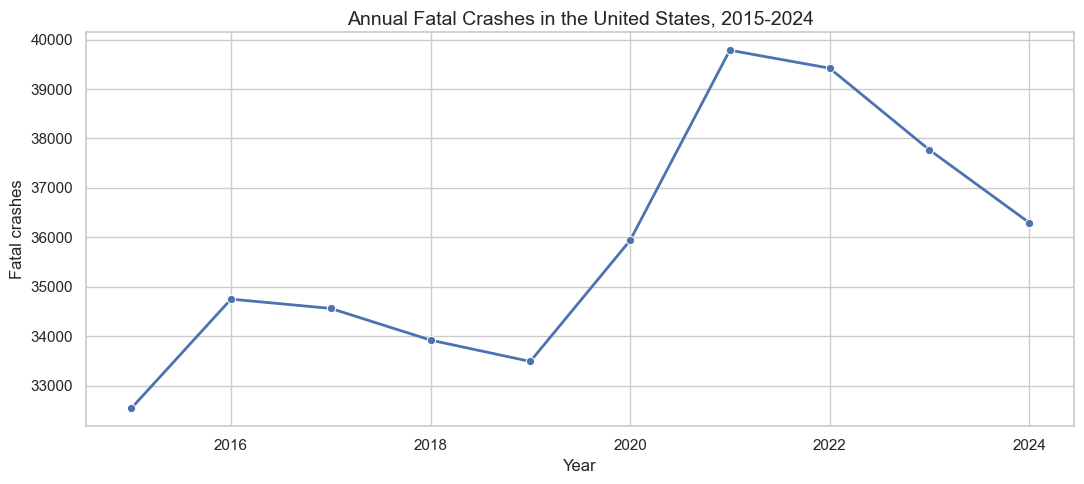

In [36]:
# plot fatal crashes per year
plt.figure(figsize=(11, 5))
sns.lineplot(data=annual_trend, x="YEAR", y="fatal_crashes", marker="o", linewidth=2)
plt.title("Annual Fatal Crashes in the United States, 2015-2024")
plt.xlabel("Year")
plt.ylabel("Fatal crashes")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_annual_fatal_crashes.png", dpi=300, bbox_inches="tight")
plt.show()

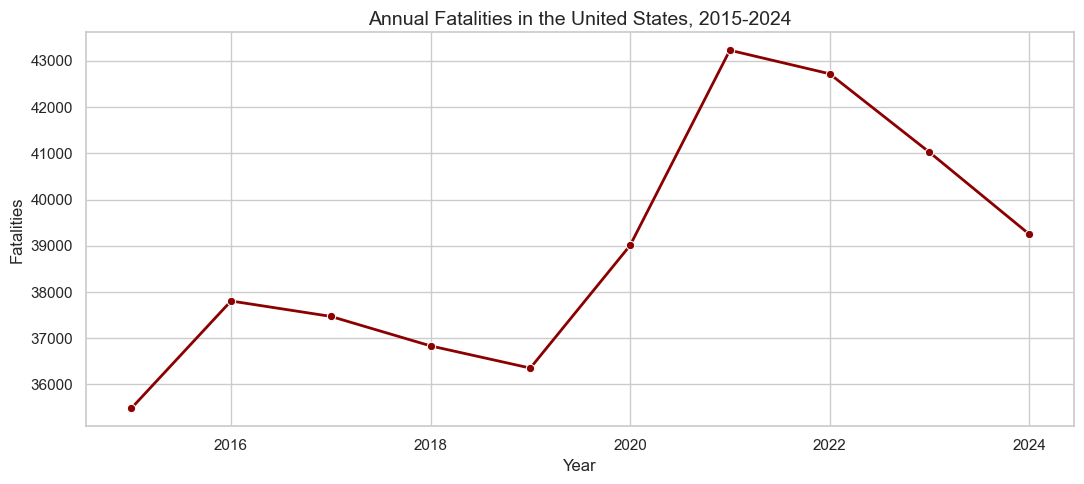

In [37]:
# plot fatalities per year
plt.figure(figsize=(11, 5))
sns.lineplot(data=annual_trend, x="YEAR", y="fatalities", marker="o", linewidth=2, color="darkred")
plt.title("Annual Fatalities in the United States, 2015-2024")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_annual_fatalities.png", dpi=300, bbox_inches="tight")
plt.show()

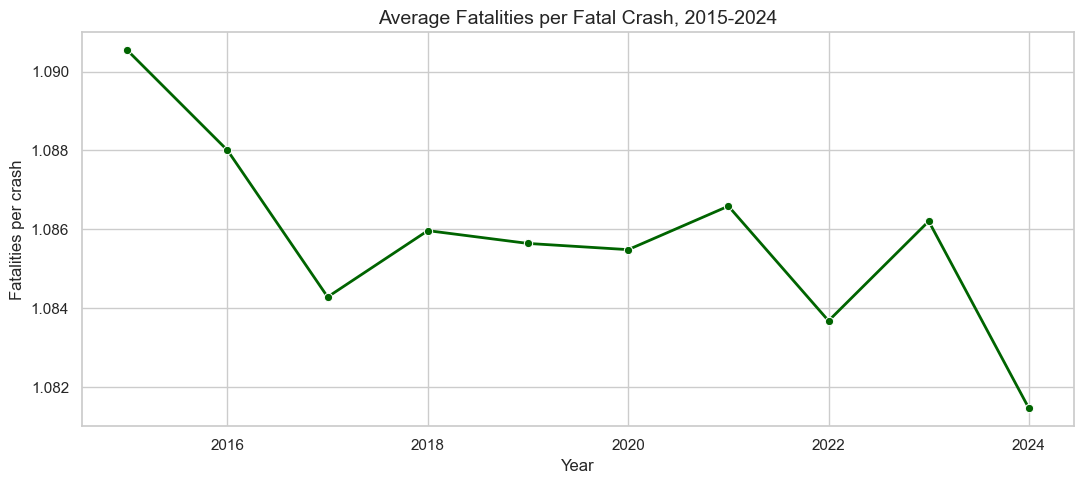

In [38]:
# plot average fatalities per fatal crash
plt.figure(figsize=(11, 5))
sns.lineplot(data=annual_trend, x="YEAR", y="avg_fatalities_per_crash", marker="o", linewidth=2, color="darkgreen")
plt.title("Average Fatalities per Fatal Crash, 2015-2024")
plt.xlabel("Year")
plt.ylabel("Fatalities per crash")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_annual_avg_fatalities_per_crash.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.2 Risk factor trend

In [39]:
# compute each risk factor's share of fatal crashes by year
annual_risk = (state_month_panel.groupby("YEAR", as_index=False)
               .agg(fatal_crashes=("fatal_crashes", "sum"),
                    alcohol_crashes=("alcohol_crashes", "sum"),
                    speed_crashes=("speed_crashes", "sum"),
                    pedestrian_crashes=("pedestrian_crashes", "sum"),
                    dark_crashes=("dark_crashes", "sum"),
                    rural_crashes=("rural_crashes", "sum"),
                    adverse_weather_crashes=("adverse_weather_crashes", "sum"),
                    weekend_crashes=("weekend_crashes", "sum"),
                    young_driver_crashes=("young_driver_crashes", "sum"),
                    unrestrained_crashes=("unrestrained_crashes", "sum")))

annual_risk["alcohol_share"] = annual_risk["alcohol_crashes"] / annual_risk["fatal_crashes"]
annual_risk["speed_share"] = annual_risk["speed_crashes"] / annual_risk["fatal_crashes"]
annual_risk["pedestrian_share"] = annual_risk["pedestrian_crashes"] / annual_risk["fatal_crashes"]
annual_risk["dark_share"] = annual_risk["dark_crashes"] / annual_risk["fatal_crashes"]
annual_risk["rural_share"] = annual_risk["rural_crashes"] / annual_risk["fatal_crashes"]
annual_risk["adverse_weather_share"] = annual_risk["adverse_weather_crashes"] / annual_risk["fatal_crashes"]
annual_risk["weekend_share"] = annual_risk["weekend_crashes"] / annual_risk["fatal_crashes"]
annual_risk["young_driver_share"] = annual_risk["young_driver_crashes"] / annual_risk["fatal_crashes"]
annual_risk["unrestrained_share"] = annual_risk["unrestrained_crashes"] / annual_risk["fatal_crashes"]

annual_risk

,YEAR,fatal_crashes,alcohol_crashes,speed_crashes,pedestrian_crashes,dark_crashes,rural_crashes,adverse_weather_crashes,weekend_crashes,young_driver_crashes,unrestrained_crashes,alcohol_share,speed_share,pedestrian_share,dark_share,rural_share,adverse_weather_share,weekend_share,young_driver_share,unrestrained_share
0,2015,32538,9215,8706,6485,15443,15860,3443,10957,8677,0,0.283207,0.267564,0.199305,0.474614,0.487430,0.105815,0.336745,0.266673,0.000000
1,2016,34748,9308,9262,7103,16700,16462,3069,11512,9119,0,0.267872,0.266548,0.204415,0.480603,0.473754,0.088322,0.331300,0.262432,0.000000
2,2017,34560,9296,8955,7037,16489,15745,3452,11343,8734,11752,0.268981,0.259115,0.203617,0.477112,0.455584,0.099884,0.328212,0.252720,0.340046
3,2018,33919,8708,8632,7392,16375,14433,3756,10935,8337,11428,0.256729,0.254489,0.217931,0.482768,0.425514,0.110734,0.322386,0.245791,0.336920
4,2019,33487,8647,8650,7335,16022,14626,3472,10774,7988,16216,0.258220,0.258309,0.219040,0.478454,0.436767,0.103682,0.321737,0.238540,0.484248
5,2020,35935,9586,10286,7698,17708,14734,3470,11818,8738,18522,0.266759,0.286239,0.214220,0.492779,0.410018,0.096563,0.328872,0.243161,0.515431
6,2021,39785,10458,11218,8663,19852,15548,3616,13067,9876,20273,0.262863,0.281966,0.217745,0.498982,0.390801,0.090889,0.328440,0.248234,0.509564
7,2022,39422,10318,10934,8936,19730,15633,3452,13120,9441,19795,0.261732,0.277358,0.226675,0.500482,0.396555,0.087565,0.332809,0.239486,0.502131
8,2023,37769,9665,10657,8771,18956,15064,3471,12654,9419,18929,0.255898,0.282163,0.232227,0.501893,0.398846,0.091901,0.335037,0.249384,0.501178
9,2024,36297,8990,10203,8454,18066,14442,3268,11815,8927,17989,0.247679,0.281098,0.232912,0.497727,0.397884,0.090035,0.325509,0.245943,0.495606


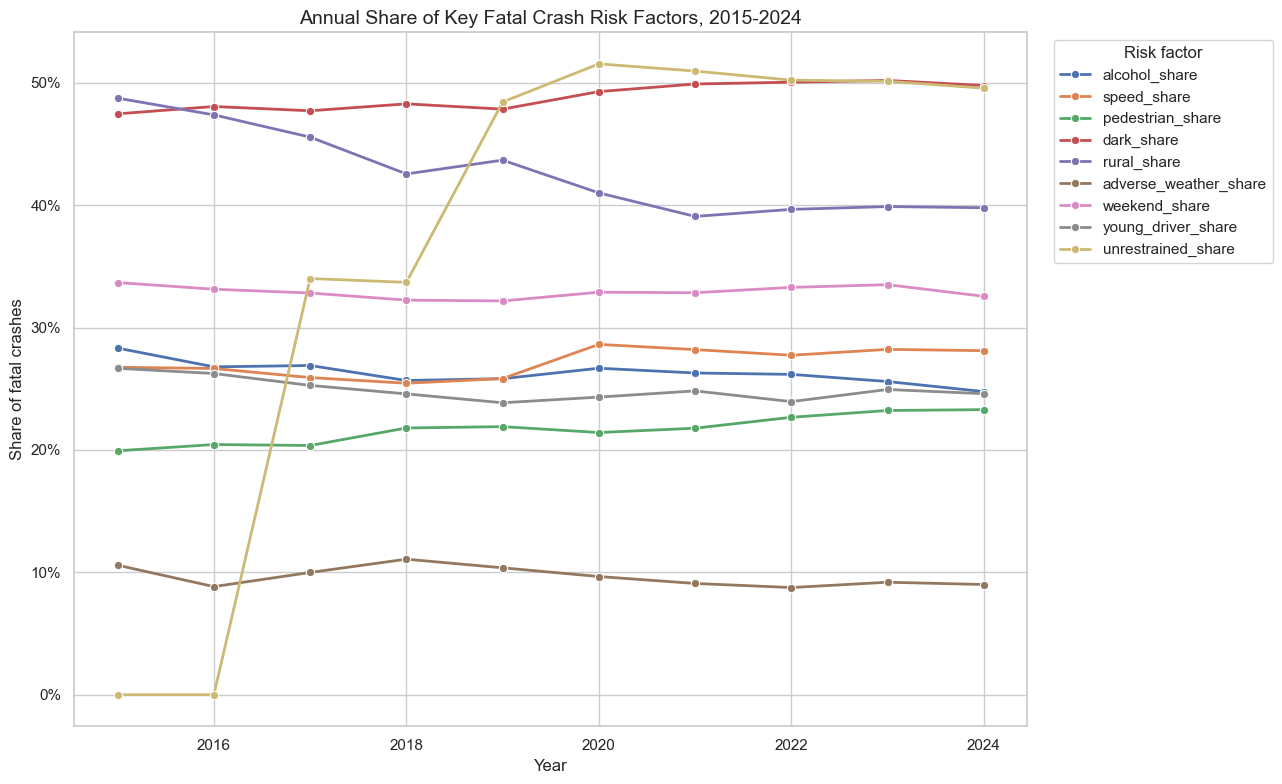

In [40]:
# plot each risk factor's share over the years on one line chart
risk_share_long = annual_risk.melt(
    id_vars=["YEAR"],
    value_vars=["alcohol_share", "speed_share", "pedestrian_share", "dark_share", "rural_share",
                "adverse_weather_share", "weekend_share", "young_driver_share", "unrestrained_share"],
    var_name="risk_factor", value_name="share")

plt.figure(figsize=(13, 8))
sns.lineplot(data=risk_share_long, x="YEAR", y="share", hue="risk_factor", marker="o", linewidth=2)
plt.title("Annual Share of Key Fatal Crash Risk Factors, 2015-2024")
plt.xlabel("Year")
plt.ylabel("Share of fatal crashes")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.legend(title="Risk factor", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_annual_risk_factor_shares.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.3 Top 10 states by fatal crashes in 2024

In [41]:
# compute each state's crash counts in 2024 and take the top 10 by fatal crashes
state_2024 = (state_month_panel.query("YEAR == 2024")
              .groupby(["STATE", "STATENAME"], as_index=False)
              .agg(fatal_crashes=("fatal_crashes", "sum"),
                   fatalities=("fatalities", "sum"),
                   alcohol_crashes=("alcohol_crashes", "sum"),
                   speed_crashes=("speed_crashes", "sum"),
                   pedestrian_crashes=("pedestrian_crashes", "sum"),
                   dark_crashes=("dark_crashes", "sum"),
                   rural_crashes=("rural_crashes", "sum")))
top10_crashes_2024 = state_2024.sort_values("fatal_crashes", ascending=False).head(10)

top10_crashes_2024

,STATE,STATENAME,fatal_crashes,fatalities,alcohol_crashes,speed_crashes,pedestrian_crashes,dark_crashes,rural_crashes
43,48,Texas,3774,4160,938,1346,860,2145,1298
4,6,California,3583,3876,954,1031,1303,2162,935
9,12,Florida,2931,3138,475,313,916,1649,569
33,37,North Carolina,1509,1619,314,616,314,715,925
10,13,Georgia,1312,1403,215,307,316,667,454
2,4,Arizona,1118,1229,250,394,304,544,310
42,47,Tennessee,1093,1197,274,190,177,517,442
13,17,Illinois,1085,1177,255,376,251,536,338
35,39,Ohio,1077,1157,313,181,154,463,452
38,42,Pennsylvania,1060,1127,256,396,199,450,405


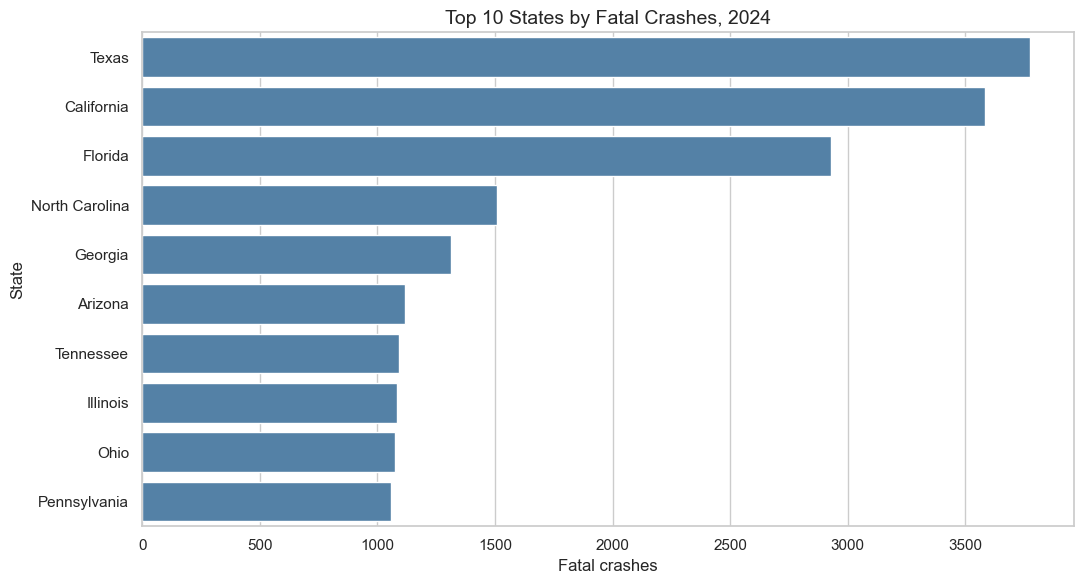

In [42]:
# plot the top 10 states by fatal crashes in 2024
plt.figure(figsize=(11, 6))
sns.barplot(data=top10_crashes_2024, x="fatal_crashes", y="STATENAME", color="steelblue")
plt.title("Top 10 States by Fatal Crashes, 2024")
plt.xlabel("Fatal crashes")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_top10_states_fatal_crashes_2024.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.4 Top 10 states by fatalities in 2024

In [43]:
# take the top 10 states by fatalities in 2024
top10_fatalities_2024 = state_2024.sort_values("fatalities", ascending=False).head(10)

top10_fatalities_2024

,STATE,STATENAME,fatal_crashes,fatalities,alcohol_crashes,speed_crashes,pedestrian_crashes,dark_crashes,rural_crashes
43,48,Texas,3774,4160,938,1346,860,2145,1298
4,6,California,3583,3876,954,1031,1303,2162,935
9,12,Florida,2931,3138,475,313,916,1649,569
33,37,North Carolina,1509,1619,314,616,314,715,925
10,13,Georgia,1312,1403,215,307,316,667,454
2,4,Arizona,1118,1229,250,394,304,544,310
42,47,Tennessee,1093,1197,274,190,177,517,442
13,17,Illinois,1085,1177,255,376,251,536,338
35,39,Ohio,1077,1157,313,181,154,463,452
38,42,Pennsylvania,1060,1127,256,396,199,450,405


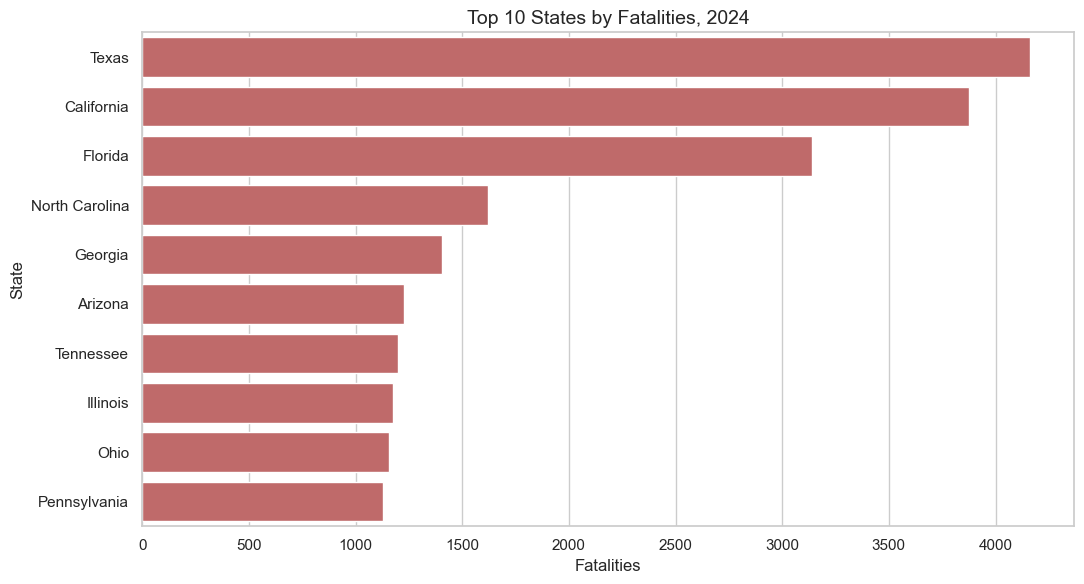

In [44]:
# plot the top 10 states by fatalities in 2024
plt.figure(figsize=(11, 6))
sns.barplot(data=top10_fatalities_2024, x="fatalities", y="STATENAME", color="indianred")
plt.title("Top 10 States by Fatalities, 2024")
plt.xlabel("Fatalities")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_top10_states_fatalities_2024.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.5 Selected state risk profiles

In [45]:
# compute risk factor shares per state and pick a few focus states to compare
focus_states = ["Texas", "California", "Florida", "North Carolina", "Georgia"]
state_2024_profile = state_2024.copy()
state_2024_profile["alcohol_share"] = state_2024_profile["alcohol_crashes"] / state_2024_profile["fatal_crashes"]
state_2024_profile["speed_share"] = state_2024_profile["speed_crashes"] / state_2024_profile["fatal_crashes"]
state_2024_profile["pedestrian_share"] = state_2024_profile["pedestrian_crashes"] / state_2024_profile["fatal_crashes"]
state_2024_profile["dark_share"] = state_2024_profile["dark_crashes"] / state_2024_profile["fatal_crashes"]
state_2024_profile["rural_share"] = state_2024_profile["rural_crashes"] / state_2024_profile["fatal_crashes"]

focus_state_profile = state_2024_profile[state_2024_profile["STATENAME"].isin(focus_states)].copy()

focus_state_profile[["STATENAME", "fatal_crashes", "fatalities", "alcohol_share",
                     "speed_share", "pedestrian_share", "dark_share", "rural_share"]]

,STATENAME,fatal_crashes,fatalities,alcohol_share,speed_share,pedestrian_share,dark_share,rural_share
4,California,3583,3876,0.266257,0.287748,0.363662,0.603405,0.260955
9,Florida,2931,3138,0.162061,0.106789,0.312521,0.562607,0.194132
10,Georgia,1312,1403,0.163872,0.233994,0.240854,0.508384,0.346037
33,North Carolina,1509,1619,0.208085,0.408217,0.208085,0.473824,0.612989
43,Texas,3774,4160,0.248543,0.356651,0.227875,0.568362,0.343932


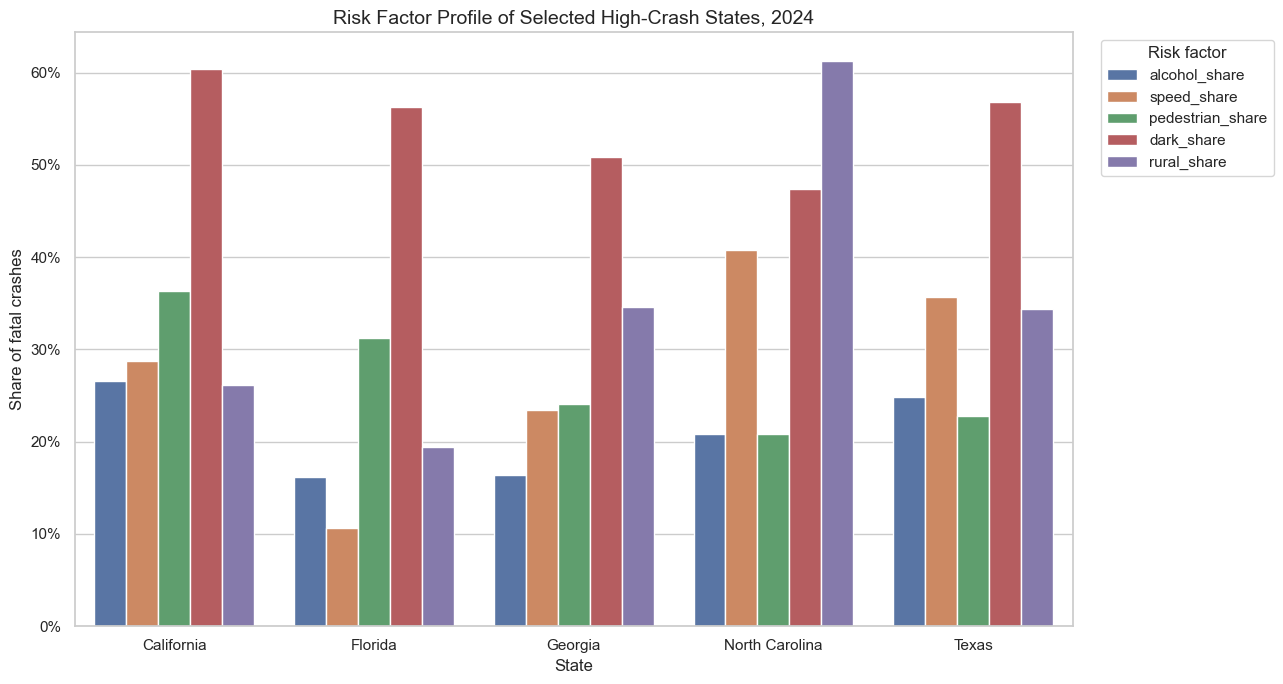

In [46]:
# plot the risk factor shares of the focus states as grouped bars
profile_long = focus_state_profile.melt(
    id_vars=["STATENAME"],
    value_vars=["alcohol_share", "speed_share", "pedestrian_share", "dark_share", "rural_share"],
    var_name="risk_factor", value_name="share")

plt.figure(figsize=(13, 7))
sns.barplot(data=profile_long, x="STATENAME", y="share", hue="risk_factor")
plt.title("Risk Factor Profile of Selected High-Crash States, 2024")
plt.xlabel("State")
plt.ylabel("Share of fatal crashes")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.legend(title="Risk factor", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_selected_state_risk_profiles_2024.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.6 Monthly pattern

In [48]:
# aggregate by month to see fatal crashes and average fatalities per crash across the year
monthly_pattern = (state_month_panel.groupby("MONTH", as_index=False)
                   .agg(fatal_crashes=("fatal_crashes", "sum"), fatalities=("fatalities", "sum")))
monthly_pattern["avg_fatalities_per_crash"] = monthly_pattern["fatalities"] / monthly_pattern["fatal_crashes"]

monthly_pattern

,MONTH,fatal_crashes,fatalities,avg_fatalities_per_crash
0,1,26045,28199,1.082703
1,2,23952,26090,1.089262
2,3,26983,29413,1.090057
3,4,27488,29844,1.085710
4,5,30793,33543,1.089306
5,6,31442,34272,1.090007
6,7,32514,35400,1.088762
7,8,32904,35637,1.083060
8,9,32712,35326,1.079910
9,10,33505,36268,1.082465


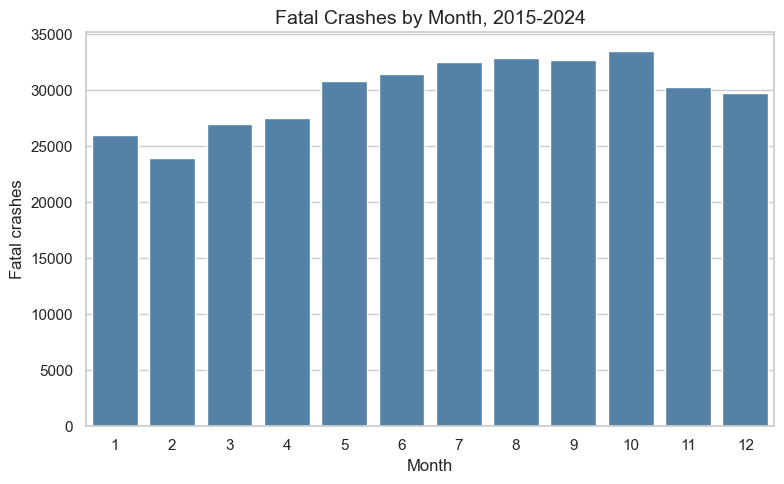

In [49]:
# plot fatal crashes by month
plt.figure(figsize=(8, 5))
sns.barplot(data=monthly_pattern, x="MONTH", y="fatal_crashes", color="steelblue")
plt.title("Fatal Crashes by Month, 2015-2024")
plt.xlabel("Month")
plt.ylabel("Fatal crashes")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_monthly_fatal_crashes.png", dpi=300, bbox_inches="tight")
plt.show()

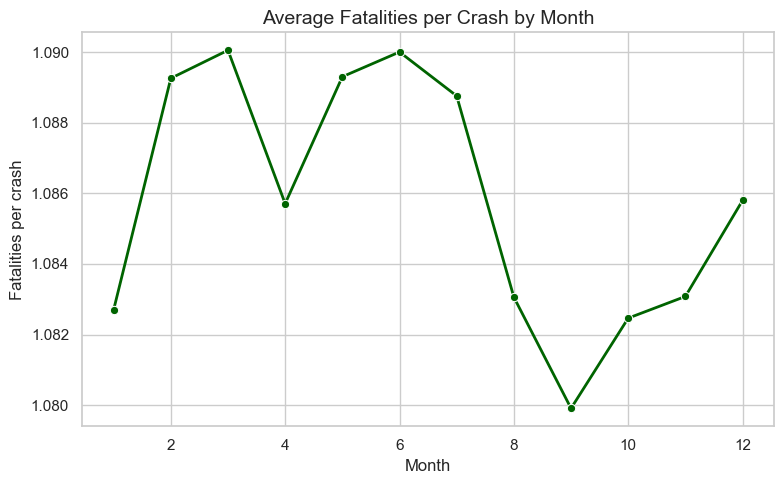

In [50]:
# plot average fatalities per crash by month
plt.figure(figsize=(8, 5))
sns.lineplot(data=monthly_pattern, x="MONTH", y="avg_fatalities_per_crash", marker="o", linewidth=2, color="darkgreen")
plt.title("Average Fatalities per Crash by Month")
plt.xlabel("Month")
plt.ylabel("Fatalities per crash")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_monthly_avg_fatalities_per_crash.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.7 Correlation heatmap

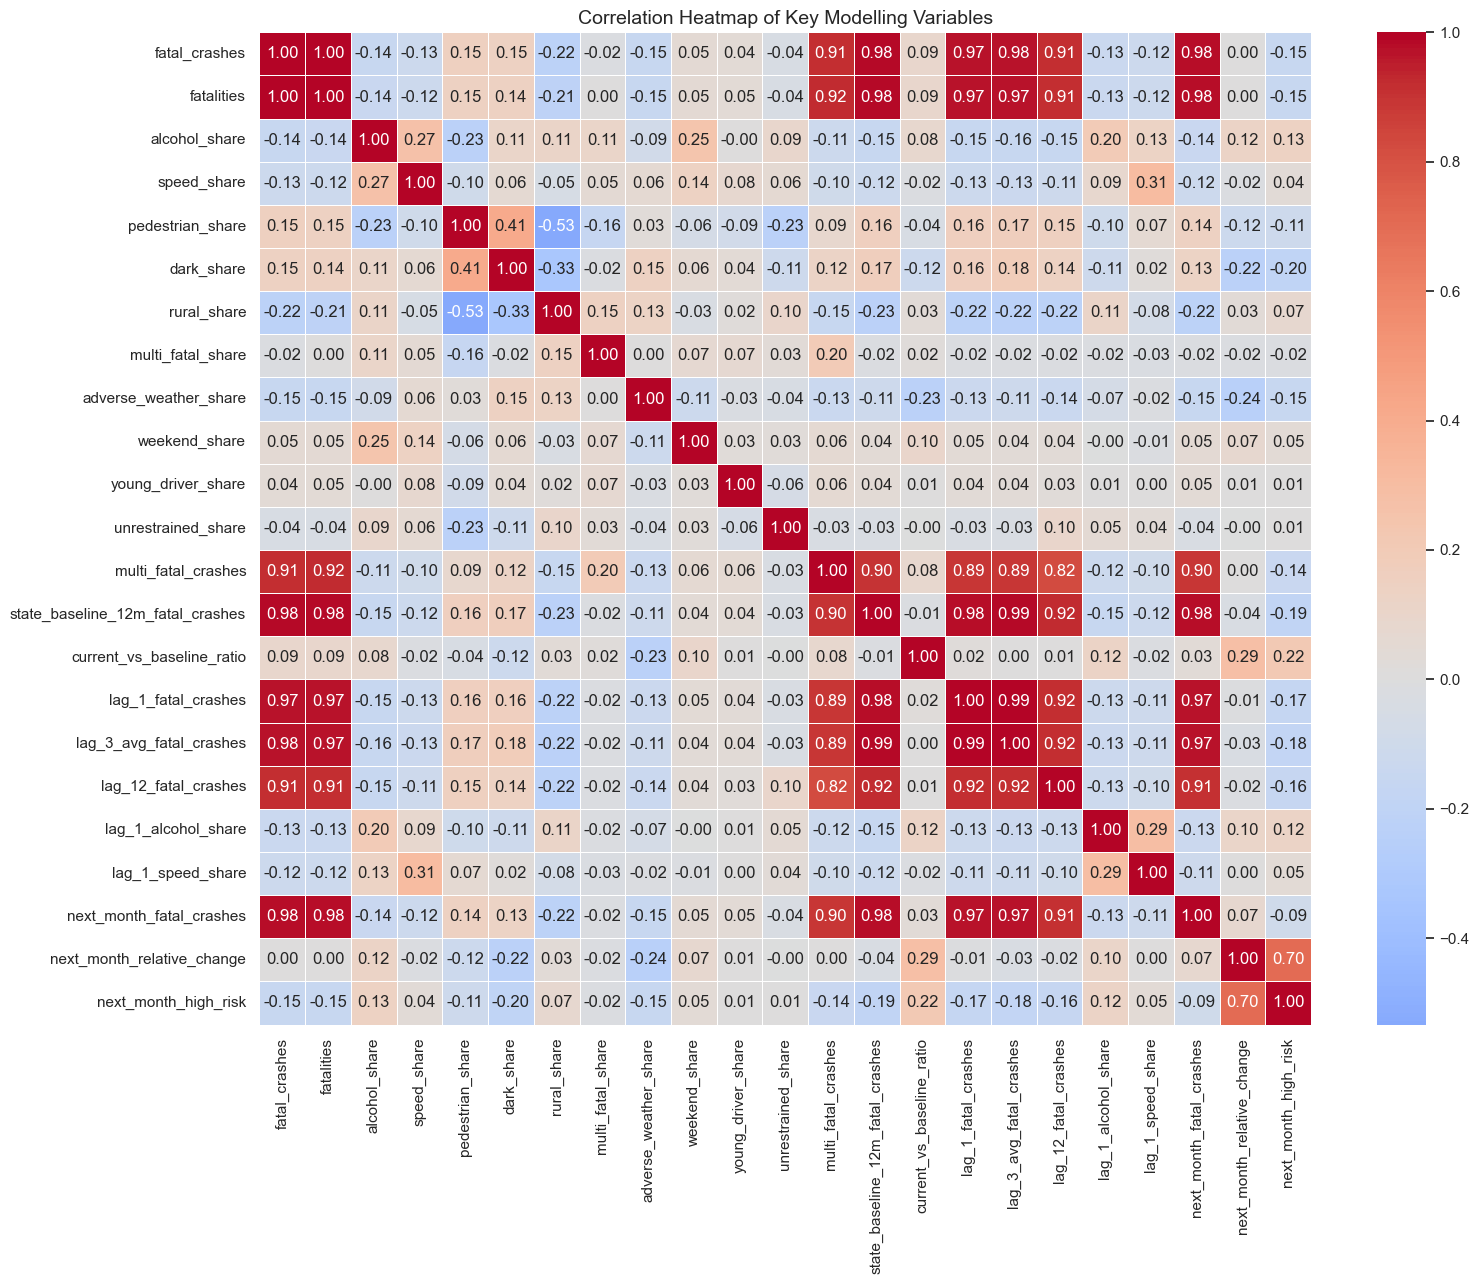

In [51]:
# correlation heatmap of the modelling variables
corr_cols = ["fatal_crashes", "fatalities", "alcohol_share", "speed_share", "pedestrian_share",
             "dark_share", "rural_share", "multi_fatal_share", "adverse_weather_share", "weekend_share",
             "young_driver_share", "unrestrained_share", "multi_fatal_crashes",
             "state_baseline_12m_fatal_crashes", "current_vs_baseline_ratio", "lag_1_fatal_crashes",
             "lag_3_avg_fatal_crashes", "lag_12_fatal_crashes", "lag_1_alcohol_share", "lag_1_speed_share",
             "next_month_fatal_crashes", "next_month_relative_change", "next_month_high_risk"]
corr_matrix = model_panel[corr_cols].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Key Modelling Variables")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_model_variable_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.8 EDA summary

In [52]:
# top 5 states by fatal crashes in 2024
top5_2024_states = (state_2024.sort_values("fatal_crashes", ascending=False)
                    .head(5)[["STATENAME", "fatal_crashes", "fatalities"]].reset_index(drop=True))

top5_2024_states

,STATENAME,fatal_crashes,fatalities
0,Texas,3774,4160
1,California,3583,3876
2,Florida,2931,3138
3,North Carolina,1509,1619
4,Georgia,1312,1403


In [53]:
# national shares of the main risk factors in the latest year (2024)
latest_year = int(annual_risk["YEAR"].max())
latest_year_risk = annual_risk.loc[annual_risk["YEAR"] == latest_year].iloc[0]
risk_summary_latest_year = pd.DataFrame({
    "risk_factor": ["alcohol_share", "speed_share", "pedestrian_share", "dark_share", "rural_share"],
    "share": [latest_year_risk["alcohol_share"], latest_year_risk["speed_share"],
              latest_year_risk["pedestrian_share"], latest_year_risk["dark_share"], latest_year_risk["rural_share"]]})
risk_summary_latest_year["share_percent"] = (risk_summary_latest_year["share"] * 100).round(2)

risk_summary_latest_year

,risk_factor,share,share_percent
0,alcohol_share,0.247679,24.77
1,speed_share,0.281098,28.11
2,pedestrian_share,0.232912,23.29
3,dark_share,0.497727,49.77
4,rural_share,0.397884,39.79


In [ ]:
# risk factor shares of the focus states in 2024
focus_state_profile[["STATENAME", "fatal_crashes", "fatalities", "alcohol_share",
                     "speed_share", "pedestrian_share", "dark_share", "rural_share"]].round(
    {"alcohol_share": 4, "speed_share": 4, "pedestrian_share": 4, "dark_share": 4, "rural_share": 4})

,STATENAME,fatal_crashes,fatalities,alcohol_share,speed_share,pedestrian_share,dark_share,rural_share
4,California,3583,3876,0.2663,0.2877,0.3637,0.6034,0.2610
9,Florida,2931,3138,0.1621,0.1068,0.3125,0.5626,0.1941
10,Georgia,1312,1403,0.1639,0.2340,0.2409,0.5084,0.3460
33,North Carolina,1509,1619,0.2081,0.4082,0.2081,0.4738,0.6130
43,Texas,3774,4160,0.2485,0.3567,0.2279,0.5684,0.3439


## 3. Q1 Statistical Inference

In [55]:
# import the libraries for regression and make folders for tables and figures
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

TABLE_DIR = Path("output/tables")
FIGURE_DIR = Path("output/figures")
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [56]:
# prepare the Q1 regression data: outcome is whether multi-fatal, predictors are the risk factors, convert to numbers and drop missing
q1_data = crash_full_features.copy()
q1_data["young_driver_involved"] = q1_data["has_young_driver"]

q1_required_cols = ["multi_fatal_crash", "alcohol_related", "speed_related", "pedestrian_involved",
                    "rural", "dark_condition", "adverse_weather", "weekend", "young_driver_involved",
                    "unrestrained_occupant", "MONTH", "YEAR", "STATE"]
for col in q1_required_cols:
    q1_data[col] = pd.to_numeric(q1_data[col], errors="coerce")

q1_model_data = q1_data[q1_required_cols].dropna().copy()
q1_model_data["multi_fatal_crash"] = q1_model_data["multi_fatal_crash"].astype(int)

q1_model_data.head()

,multi_fatal_crash,alcohol_related,speed_related,pedestrian_involved,rural,dark_condition,adverse_weather,weekend,young_driver_involved,unrestrained_occupant,MONTH,YEAR,STATE
0,0,1,0,0,1,1,0,0,0,0,1,2015,1
1,0,0,1,0,1,1,0,0,0,0,1,2015,1
2,0,1,0,0,1,1,0,0,0,0,1,2015,1
3,0,1,0,0,1,1,0,1,0,0,1,2015,1
4,0,0,0,0,0,0,0,0,1,0,1,2015,1


In [57]:
# check the distribution of the outcome (whether multi-fatal)
print(q1_model_data["multi_fatal_crash"].value_counts())
print(q1_model_data["multi_fatal_crash"].value_counts(normalize=True).round(4))

multi_fatal_crash
0    333455
1     25005
Name: count, dtype: int64
multi_fatal_crash
0    0.9302
1    0.0698
Name: proportion, dtype: float64


### 3.1 Baseline logistic model

In [58]:
# run a baseline logistic regression with the 5 main risk factors
baseline_formula = """
multi_fatal_crash ~ alcohol_related
                  + speed_related
                  + pedestrian_involved
                  + rural
                  + dark_condition
"""
baseline_model = smf.glm(formula=baseline_formula, data=q1_model_data,
                         family=sm.families.Binomial()).fit(cov_type="HC1")
print(baseline_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      multi_fatal_crash   No. Observations:               358460
Model:                            GLM   Df Residuals:                   358454
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -87331.
Date:                Thu, 04 Jun 2026   Deviance:                   1.7466e+05
Time:                        14:11:32   Pearson chi2:                 3.54e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01858
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.7023    

### 3.2 Full logistic model

In [59]:
# run a full model with more risk factors and month, year, state fixed effects
full_formula = """
multi_fatal_crash ~ alcohol_related
                  + speed_related
                  + pedestrian_involved
                  + rural
                  + dark_condition
                  + adverse_weather
                  + weekend
                  + young_driver_involved
                  + unrestrained_occupant
                  + C(MONTH)
                  + C(YEAR)
                  + C(STATE)
"""
full_model = smf.glm(formula=full_formula, data=q1_model_data,
                     family=sm.families.Binomial()).fit(cov_type="HC1", maxiter=100)
print(full_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      multi_fatal_crash   No. Observations:               358460
Model:                            GLM   Df Residuals:                   358380
Model Family:                Binomial   Df Model:                           79
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -86678.
Date:                Thu, 04 Jun 2026   Deviance:                   1.7336e+05
Time:                        14:11:40   Pearson chi2:                 3.54e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02216
Covariance Type:                  HC1                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -2.87

### 3.3 Save regression results

In [60]:
# tidy the baseline model coefficients into a table and compute odds ratios with confidence intervals
baseline_results = pd.DataFrame({
    "term": baseline_model.params.index, "coef": baseline_model.params.values,
    "std_error": baseline_model.bse.values, "z_value": baseline_model.tvalues.values,
    "p_value": baseline_model.pvalues.values})
baseline_results["conf_low"] = baseline_model.conf_int()[0].values
baseline_results["conf_high"] = baseline_model.conf_int()[1].values
baseline_results["odds_ratio"] = np.exp(baseline_results["coef"])
baseline_results["or_conf_low"] = np.exp(baseline_results["conf_low"])
baseline_results["or_conf_high"] = np.exp(baseline_results["conf_high"])
baseline_results["model"] = "baseline_model" 

In [61]:
# tidy the full model results the same way
full_results = pd.DataFrame({
    "term": full_model.params.index, "coef": full_model.params.values,
    "std_error": full_model.bse.values, "z_value": full_model.tvalues.values,
    "p_value": full_model.pvalues.values})
full_results["conf_low"] = full_model.conf_int()[0].values
full_results["conf_high"] = full_model.conf_int()[1].values
full_results["odds_ratio"] = np.exp(full_results["coef"])
full_results["or_conf_low"] = np.exp(full_results["conf_low"])
full_results["or_conf_high"] = np.exp(full_results["conf_high"])
full_results["model"] = "full_model" 

In [62]:
# merge both models' results and save, then pull out the main risk factors' odds ratios from the full model and flag significance
q1_regression_results = pd.concat([baseline_results, full_results], ignore_index=True)
q1_regression_results.to_csv(TABLE_DIR / "q1_regression_results.csv", index=False)

main_terms = ["alcohol_related", "speed_related", "pedestrian_involved", "rural", "dark_condition",
              "adverse_weather", "weekend", "young_driver_involved", "unrestrained_occupant"]
q1_odds_ratios = q1_regression_results.query("model == 'full_model' and term in @main_terms").copy()
q1_odds_ratios["significant_05"] = q1_odds_ratios["p_value"] < 0.05
q1_odds_ratios = q1_odds_ratios[["term", "odds_ratio", "or_conf_low", "or_conf_high", "coef",
                                 "std_error", "z_value", "p_value", "significant_05"]].sort_values("odds_ratio", ascending=False)
q1_odds_ratios.to_csv(TABLE_DIR / "q1_odds_ratios.csv", index=False)

q1_odds_ratios

,term,odds_ratio,or_conf_low,or_conf_high,coef,std_error,z_value,p_value,significant_05
84,young_driver_involved,1.498955,1.457882,1.541185,0.404768,0.014176,28.553914,2.511594e-179,True
80,rural,1.416492,1.377591,1.456492,0.348184,0.014208,24.505919,1.277418e-132,True
77,alcohol_related,1.170881,1.135721,1.207130,0.157757,0.015556,10.141200,3.626173e-24,True
78,speed_related,1.157492,1.124450,1.191506,0.146256,0.014777,9.897638,4.262245e-23,True
83,weekend,1.110687,1.080567,1.141646,0.104979,0.014027,7.484038,7.207315e-14,True
85,unrestrained_occupant,1.062851,1.029472,1.097313,0.060955,0.016281,3.744022,1.810978e-04,True
82,adverse_weather,1.046317,1.001370,1.093281,0.045276,0.022402,2.021060,4.327357e-02,True
81,dark_condition,1.039635,1.010467,1.069644,0.038869,0.014519,2.677161,7.424901e-03,True
79,pedestrian_involved,0.223396,0.209565,0.238140,-1.498809,0.032608,-45.963913,0.000000e+00,True


## 4. Q2 Machine Learning

In [66]:
# import the machine learning libraries and make folders for tables, figures and models
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, RocCurveDisplay)

TABLE_DIR = Path("output/tables")
FIGURE_DIR = Path("output/figures")
MODEL_DIR = Path("output/models")
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [67]:
# import XGBoost
from xgboost import XGBClassifier

In [68]:
# choose the feature columns (X) and target (y); target is whether next month is relatively high risk, and check the target distribution
ml_data = model_panel.copy()
target_col = "next_month_high_risk"

numeric_features = ["fatal_crashes", "fatalities", "alcohol_share", "speed_share", "pedestrian_share",
                    "dark_share", "rural_share", "multi_fatal_share", "adverse_weather_share",
                    "weekend_share", "young_driver_share", "unrestrained_share", "multi_fatal_crashes",
                    "state_baseline_12m_fatal_crashes", "current_vs_baseline_ratio", "lag_1_fatal_crashes",
                    "lag_3_avg_fatal_crashes", "lag_12_fatal_crashes", "lag_1_alcohol_share", "lag_1_speed_share"]
categorical_features = ["STATE", "MONTH"]
all_features = numeric_features + categorical_features

ml_data[target_col] = ml_data[target_col].astype(int)
print(ml_data[target_col].value_counts())
print(ml_data[target_col].value_counts(normalize=True).round(4))

next_month_high_risk
0    4706
1    1363
Name: count, dtype: int64
next_month_high_risk
0    0.7754
1    0.2246
Name: proportion, dtype: float64


In [69]:
# split the data by year: 2015-2021 train, 2022 validation, 2023-2024 test
train_mask = ml_data["YEAR"].between(2015, 2021)
valid_mask = ml_data["YEAR"] == 2022
test_mask = ml_data["YEAR"].between(2023, 2024)

X_train = ml_data.loc[train_mask, all_features].copy()
y_train = ml_data.loc[train_mask, target_col].copy()
X_valid = ml_data.loc[valid_mask, all_features].copy()
y_valid = ml_data.loc[valid_mask, target_col].copy()
X_test = ml_data.loc[test_mask, all_features].copy()
y_test = ml_data.loc[test_mask, target_col].copy()

print("Training set:", X_train.shape, y_train.value_counts(normalize=True).round(4).to_dict())
print("Validation set:", X_valid.shape, y_valid.value_counts(normalize=True).round(4).to_dict())
print("Test set:", X_test.shape, y_test.value_counts(normalize=True).round(4).to_dict())

Training set: (4284, 22) {0: 0.7586, 1: 0.2414}
Validation set: (612, 22) {0: 0.8072, 1: 0.1928}
Test set: (1173, 22) {0: 0.8201, 1: 0.1799}


In [70]:
# set up preprocessing: numeric columns impute with median and scale when needed; categorical columns impute with mode then one-hot encode
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
numeric_transformer_no_scale = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)])
preprocess_no_scale = ColumnTransformer(transformers=[
    ("num", numeric_transformer_no_scale, numeric_features),
    ("cat", categorical_transformer, categorical_features)])

In [71]:
# build four models: logistic regression, decision tree, random forest, XGBoost, all using class weighting for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocess_scaled),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced",
                                     solver="liblinear", random_state=42))]),
    "Decision Tree": Pipeline(steps=[
        ("preprocess", preprocess_no_scale),
        ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=30,
                                         class_weight="balanced", random_state=42))]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess_no_scale),
        ("model", RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=10,
                                         class_weight="balanced", random_state=42, n_jobs=-1))]),
    "XGBoost": Pipeline(steps=[
        ("preprocess", preprocess_no_scale),
        ("model", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                                colsample_bytree=0.8, eval_metric="logloss",
                                scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1))])}
print(list(models.keys()))

['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


In [72]:
# train each model and compute AUC, accuracy, precision, recall, F1 on validation and test, collect into one table and save
trained_models = {}
performance_records = []
for model_name, model_pipeline in models.items():
    model_pipeline.fit(X_train, y_train)
    trained_models[model_name] = model_pipeline

    valid_pred = model_pipeline.predict(X_valid)
    valid_prob = model_pipeline.predict_proba(X_valid)[:, 1]
    performance_records.append({
        "model": model_name, "dataset": "validation_2022",
        "auc": roc_auc_score(y_valid, valid_prob), "accuracy": accuracy_score(y_valid, valid_pred),
        "precision": precision_score(y_valid, valid_pred, zero_division=0),
        "recall": recall_score(y_valid, valid_pred, zero_division=0),
        "f1": f1_score(y_valid, valid_pred, zero_division=0)})

    test_pred = model_pipeline.predict(X_test)
    test_prob = model_pipeline.predict_proba(X_test)[:, 1]
    performance_records.append({
        "model": model_name, "dataset": "test_2023_2024",
        "auc": roc_auc_score(y_test, test_prob), "accuracy": accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1": f1_score(y_test, test_pred, zero_division=0)})

q2_model_performance = pd.DataFrame(performance_records).sort_values(["dataset", "auc"], ascending=[True, False])
q2_model_performance.to_csv(TABLE_DIR / "q2_model_performance.csv", index=False, encoding="utf-8-sig")

q2_model_performance

,model,dataset,auc,accuracy,precision,recall,f1
1,Logistic Regression,test_2023_2024,0.817723,0.709292,0.356828,0.767773,0.487218
5,Random Forest,test_2023_2024,0.806461,0.756181,0.396122,0.677725,0.500000
7,XGBoost,test_2023_2024,0.801736,0.705030,0.347630,0.729858,0.470948
3,Decision Tree,test_2023_2024,0.731853,0.622336,0.290614,0.763033,0.420915
6,XGBoost,validation_2022,0.788136,0.718954,0.370192,0.652542,0.472393
4,Random Forest,validation_2022,0.777431,0.740196,0.386740,0.593220,0.468227
0,Logistic Regression,validation_2022,0.771495,0.720588,0.381166,0.720339,0.498534
2,Decision Tree,validation_2022,0.708639,0.614379,0.292254,0.703390,0.412935


### 4.1 Compare model performance

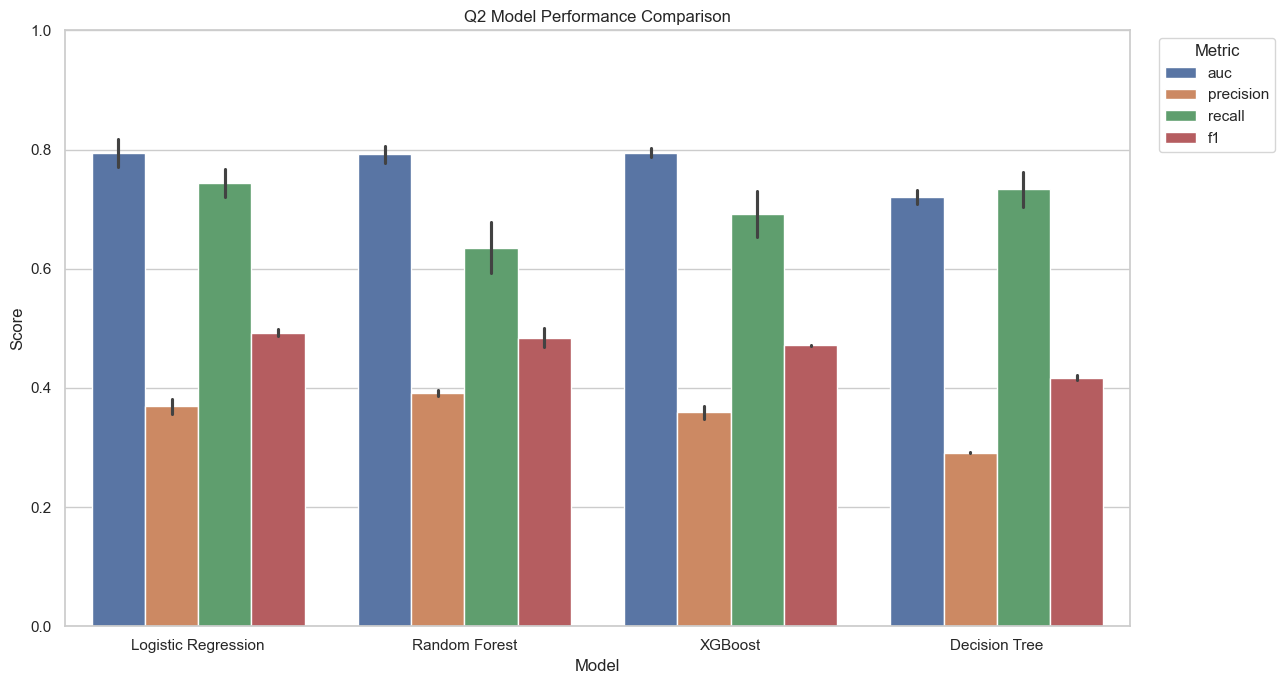

In [73]:
# plot the models' metrics as grouped bars for comparison
performance_long = q2_model_performance.melt(
    id_vars=["model", "dataset"], value_vars=["auc", "precision", "recall", "f1"],
    var_name="metric", value_name="score")
plt.figure(figsize=(13, 7))
sns.barplot(data=performance_long, x="model", y="score", hue="metric")
plt.title("Q2 Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q2_model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.2 Choose best model

In [74]:
# pick the best model by test AUC and recall
test_performance = q2_model_performance.query("dataset == 'test_2023_2024'").copy()
best_model_name = test_performance.sort_values(["auc", "recall"], ascending=False).iloc[0]["model"]
best_model = trained_models[best_model_name]

test_performance.sort_values(["auc", "recall"], ascending=False)

,model,dataset,auc,accuracy,precision,recall,f1
1,Logistic Regression,test_2023_2024,0.817723,0.709292,0.356828,0.767773,0.487218
5,Random Forest,test_2023_2024,0.806461,0.756181,0.396122,0.677725,0.500000
7,XGBoost,test_2023_2024,0.801736,0.705030,0.347630,0.729858,0.470948
3,Decision Tree,test_2023_2024,0.731853,0.622336,0.290614,0.763033,0.420915


### 4.3 Confusion matrix

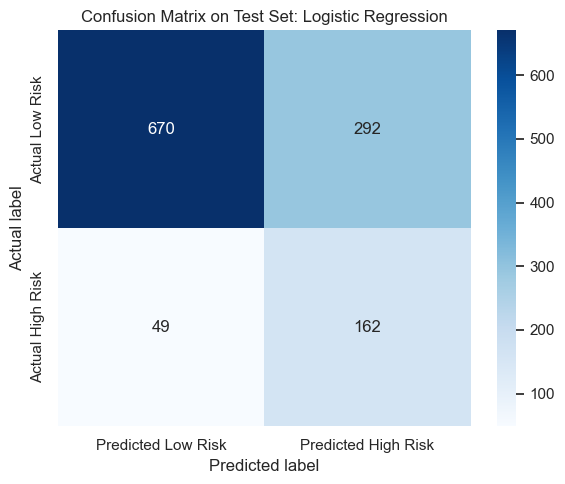

In [75]:
# plot the best model's confusion matrix on the test set
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Low Risk", "Predicted High Risk"],
            yticklabels=["Actual Low Risk", "Actual High Risk"])
plt.title(f"Confusion Matrix on Test Set: {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q2_best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
# print the best model's detailed classification report on the test set
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.93      0.70      0.80       962
           1       0.36      0.77      0.49       211

    accuracy                           0.71      1173
   macro avg       0.64      0.73      0.64      1173
weighted avg       0.83      0.71      0.74      1173



### 4.4 ROC curves

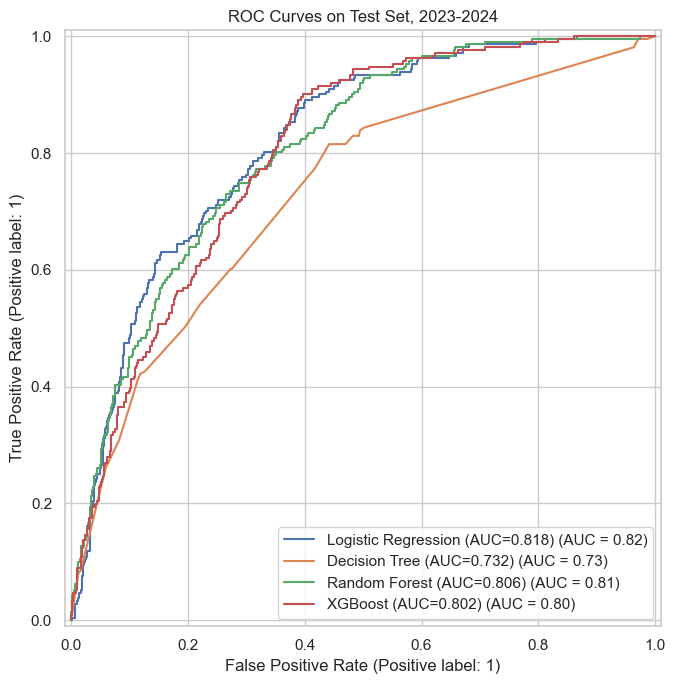

In [77]:
# plot all models' ROC curves on the test set together
plt.figure(figsize=(8, 7))
for model_name, fitted_model in trained_models.items():
    y_prob = fitted_model.predict_proba(X_test)[:, 1]
    auc_value = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(y_test, y_prob, name=f"{model_name} (AUC={auc_value:.3f})", ax=plt.gca())
plt.title("ROC Curves on Test Set, 2023-2024")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q2_roc_curves_test_set.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.5 Test predictions

In [78]:
# combine each test state-month's actual values with the model's predicted probability, sort by probability and save
test_predictions = ml_data.loc[test_mask, [
    "STATE", "STATENAME", "YEAR", "MONTH", "fatal_crashes", "fatalities",
    "state_baseline_12m_fatal_crashes", "current_vs_baseline_ratio", "alcohol_share", "speed_share",
    "pedestrian_share", "dark_share", "rural_share", "adverse_weather_share", "weekend_share",
    "young_driver_share", "unrestrained_share", "next_month_fatal_crashes",
    "next_month_relative_change", "next_month_high_risk"]].copy()
test_predictions["predicted_high_risk"] = y_test_pred
test_predictions["predicted_risk_probability"] = y_test_prob
test_predictions = test_predictions.sort_values("predicted_risk_probability", ascending=False).reset_index(drop=True)
test_predictions.to_csv(TABLE_DIR / "q2_predictions_2023_2024.csv", index=False, encoding="utf-8-sig")

test_predictions.head(20)

,STATE,STATENAME,YEAR,MONTH,fatal_crashes,fatalities,state_baseline_12m_fatal_crashes,current_vs_baseline_ratio,alcohol_share,speed_share,...,rural_share,adverse_weather_share,weekend_share,young_driver_share,unrestrained_share,next_month_fatal_crashes,next_month_relative_change,next_month_high_risk,predicted_high_risk,predicted_risk_probability
0,11,District of Columbia,2024,6,9,9,3.833333,2.347826,0.111111,0.111111,...,0.000000,0.000000,0.111111,0.111111,0.444444,4,0.043478,0,1,0.885441
1,11,District of Columbia,2023,6,5,5,2.916667,1.714286,0.200000,0.200000,...,0.000000,0.000000,0.400000,0.200000,0.600000,3,0.028571,0,1,0.880536
2,2,Alaska,2024,6,7,7,4.916667,1.423729,0.285714,0.571429,...,0.571429,0.000000,0.428571,0.285714,0.285714,6,0.220339,1,1,0.878893
3,50,Vermont,2023,5,12,15,5.833333,2.057143,0.333333,0.250000,...,1.000000,0.000000,0.250000,0.333333,0.750000,5,-0.142857,0,1,0.872949
4,44,Rhode Island,2023,8,7,7,5.666667,1.235294,0.142857,0.428571,...,0.142857,0.000000,0.000000,0.285714,0.428571,5,-0.117647,0,1,0.871276
5,44,Rhode Island,2023,6,6,6,6.083333,0.986301,0.000000,0.333333,...,0.333333,0.000000,0.166667,0.166667,0.500000,5,-0.178082,0,1,0.868590
6,50,Vermont,2024,9,3,3,4.500000,0.666667,0.666667,0.666667,...,1.000000,0.000000,0.666667,0.000000,0.666667,5,0.111111,0,1,0.868147
7,16,Idaho,2023,7,34,37,17.250000,1.971014,0.323529,0.205882,...,0.794118,0.000000,0.352941,0.205882,0.676471,27,0.565217,1,1,0.865550
8,50,Vermont,2024,6,6,6,4.750000,1.263158,0.666667,1.000000,...,0.666667,0.000000,0.666667,0.500000,0.833333,6,0.263158,1,1,0.864538
9,50,Vermont,2024,7,6,7,4.666667,1.285714,0.833333,0.500000,...,1.000000,0.166667,0.333333,0.500000,0.500000,5,0.071429,0,1,0.859113


### 4.6 Top 10 predicted high-risk state-months

In [79]:
# take the 10 state-months with the highest predicted risk probability
top10_predicted_high_risk = test_predictions.head(10).copy()
top10_predicted_high_risk.to_csv(TABLE_DIR / "q2_top10_predicted_high_risk_state_months.csv",
                                 index=False, encoding="utf-8-sig")

top10_predicted_high_risk[["STATENAME", "YEAR", "MONTH", "fatal_crashes",
                           "state_baseline_12m_fatal_crashes", "current_vs_baseline_ratio",
                           "next_month_fatal_crashes", "next_month_relative_change", "next_month_high_risk",
                           "predicted_high_risk", "predicted_risk_probability",
                           "alcohol_share", "speed_share", "pedestrian_share", "dark_share", "rural_share"]]

,STATENAME,YEAR,MONTH,fatal_crashes,state_baseline_12m_fatal_crashes,current_vs_baseline_ratio,next_month_fatal_crashes,next_month_relative_change,next_month_high_risk,predicted_high_risk,predicted_risk_probability,alcohol_share,speed_share,pedestrian_share,dark_share,rural_share
0,District of Columbia,2024,6,9,3.833333,2.347826,4,0.043478,0,1,0.885441,0.111111,0.111111,0.555556,0.444444,0.000000
1,District of Columbia,2023,6,5,2.916667,1.714286,3,0.028571,0,1,0.880536,0.200000,0.200000,0.200000,0.800000,0.000000
2,Alaska,2024,6,7,4.916667,1.423729,6,0.220339,1,1,0.878893,0.285714,0.571429,0.142857,0.142857,0.571429
3,Vermont,2023,5,12,5.833333,2.057143,5,-0.142857,0,1,0.872949,0.333333,0.250000,0.000000,0.333333,1.000000
4,Rhode Island,2023,8,7,5.666667,1.235294,5,-0.117647,0,1,0.871276,0.142857,0.428571,0.142857,0.428571,0.142857
5,Rhode Island,2023,6,6,6.083333,0.986301,5,-0.178082,0,1,0.868590,0.000000,0.333333,0.166667,0.333333,0.333333
6,Vermont,2024,9,3,4.500000,0.666667,5,0.111111,0,1,0.868147,0.666667,0.666667,0.000000,1.000000,1.000000
7,Idaho,2023,7,34,17.250000,1.971014,27,0.565217,1,1,0.865550,0.323529,0.205882,0.147059,0.205882,0.794118
8,Vermont,2024,6,6,4.750000,1.263158,6,0.263158,1,1,0.864538,0.666667,1.000000,0.000000,0.333333,0.666667
9,Vermont,2024,7,6,4.666667,1.285714,5,0.071429,0,1,0.859113,0.833333,0.500000,0.000000,0.166667,1.000000


### 4.7 Plot Top 10 predictions

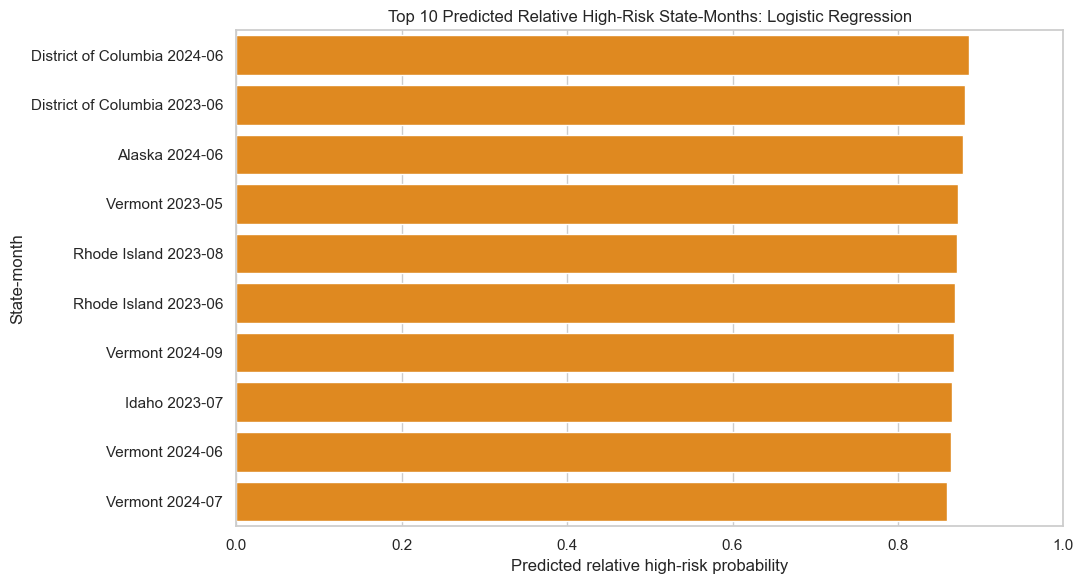

In [80]:
# plot the top 10 highest predicted-probability state-months as bars
top10_plot = top10_predicted_high_risk.copy()
top10_plot["state_month"] = (top10_plot["STATENAME"] + " " + top10_plot["YEAR"].astype(str)
                             + "-" + top10_plot["MONTH"].astype(str).str.zfill(2))
plt.figure(figsize=(11, 6))
sns.barplot(data=top10_plot, x="predicted_risk_probability", y="state_month", color="darkorange")
plt.title(f"Top 10 Predicted Relative High-Risk State-Months: {best_model_name}")
plt.xlabel("Predicted relative high-risk probability")
plt.ylabel("State-month")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q2_top10_predicted_high_risk_state_months.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.8 Feature importance

In [81]:
# get the best model's feature importances (tree models use importance, logistic uses absolute coefficients) and save
best_preprocessor = best_model.named_steps["preprocess"]
best_estimator = best_model.named_steps["model"]
cat_names = best_preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
feature_names = np.array(numeric_features + list(cat_names))

if hasattr(best_estimator, "feature_importances_"):
    importance_values = best_estimator.feature_importances_
elif hasattr(best_estimator, "coef_"):
    importance_values = np.abs(best_estimator.coef_[0])
else:
    importance_values = np.zeros(len(feature_names))

feature_importance = pd.DataFrame({"feature": feature_names, "importance": importance_values}).sort_values("importance", ascending=False)
feature_importance.to_csv(TABLE_DIR / "q2_feature_importance.csv", index=False, encoding="utf-8-sig")

feature_importance.head(20)

,feature,importance
13,state_baseline_12m_fatal_crashes,2.815266
71,MONTH_1,1.948244
63,STATE_48,1.535533
29,STATE_12,1.474794
82,MONTH_12,1.447729
76,MONTH_6,1.158403
24,STATE_6,1.141227
0,fatal_crashes,1.113450
60,STATE_45,1.047926
77,MONTH_7,1.012076


### 4.9 Plot feature importance

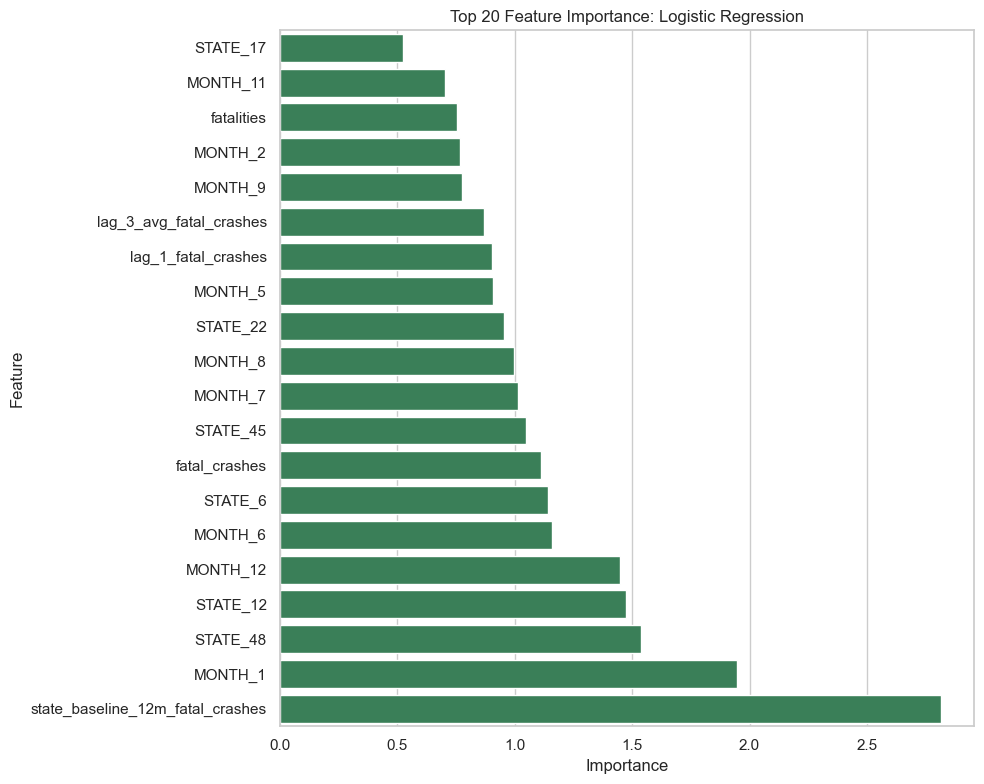

In [82]:
# plot the top 20 most important features as bars
top20_features = feature_importance.head(20).sort_values("importance", ascending=True)
plt.figure(figsize=(10, 8))
sns.barplot(data=top20_features, x="importance", y="feature", color="seagreen")
plt.title(f"Top 20 Feature Importance: {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q2_feature_importance_top20.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.10 Q2 summary

In [83]:
# finally compare the key test-set metrics of the best model and logistic regression
best_test_row = test_performance.query("model == @best_model_name").iloc[0]
baseline_test_row = test_performance.query("model == 'Logistic Regression'").iloc[0]
q2_final_compare = pd.DataFrame([best_test_row, baseline_test_row])[["model", "auc", "precision", "recall", "f1"]]

q2_final_compare

,model,auc,precision,recall,f1
1,Logistic Regression,0.817723,0.356828,0.767773,0.487218
1,Logistic Regression,0.817723,0.356828,0.767773,0.487218
